## **1. Inisialisasi Lingkungan, Akuisisi, dan Prapemrosesan Akses Data**
**Deskripsi:** Tahap ini bertanggung jawab atas tiga pilar utama infrastruktur eksperimen:
1. **Autentikasi & Koneksi:** Menghubungkan lingkungan komputasi (Google Colab) dengan sistem penyimpanan persisten (Google Drive).
2. **Akselerasi I/O (Input/Output):** Mentransfer himpunan data berukuran raksasa (*RSNA* dan *Chest X-Ray*) dari Google Drive ke penyimpanan lokal instans Colab (NVMe SSD). Langkah krusial ini mencegah terjadinya *bottleneck* pembacaan data (latensi jaringan) yang dapat memperlambat siklus pelatihan model hingga 10x lipat.
3. **Konfigurasi Global:** Menginisialisasi kelas `Config` sebagai pusat kendali parameter (*hyperparameters*) dan mendeteksi ketersediaan akselerator perangkat keras (GPU/CUDA).

In [ ]:
# 1. Import Library
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from google.colab import drive

# 2. Autentikasi dan Pemasangan Akses Google Drive
drive.mount('/content/drive')

# 3. Konfigurasi Direktori Penyimpanan (Path)
# Direktori Sumber (Penyimpanan Cloud Google Drive)
DRIVE_ZIP_PATH = '/content/drive/MyDrive/Tugas Akhir/Dataset/dataset_rsna_clean_png.zip'
DRIVE_CHEST_XRAY = '/content/drive/MyDrive/Tugas Akhir/Dataset/chest_xray'

# Direktori Tujuan (Penyimpanan Lokal Google Colab untuk akselerasi I/O)
LOCAL_RSNA_DIR = '/content/rsna_png'
LOCAL_CHEST_DIR = '/content/chest_xray'

# 4. Eksekusi Transfer Data RSNA (Data Tidak Berlabel untuk Pre-training SimCLR)
print("\n[INFO] Menginisialisasi transfer himpunan data RSNA...")
if not os.path.exists(LOCAL_RSNA_DIR):
    if os.path.exists(DRIVE_ZIP_PATH):
        os.makedirs(LOCAL_RSNA_DIR, exist_ok=True)
        print("[PROSES] Mengekstrak arsip ZIP RSNA ke penyimpanan lokal. Mohon tunggu...")
        # Ekstraksi arsip secara senyap (quiet) ke direktori tujuan
        !unzip -q "$DRIVE_ZIP_PATH" -d "$LOCAL_RSNA_DIR"
        print(f"[BERHASIL] Dataset RSNA berhasil diekstrak pada: {LOCAL_RSNA_DIR}")
    else:
        raise FileNotFoundError(f"[GAGAL] Arsip ZIP tidak ditemukan pada direktori: {DRIVE_ZIP_PATH}")
else:
    print("[INFO] Dataset RSNA telah tersedia di penyimpanan lokal.")

# 5. Eksekusi Transfer Data Chest X-Ray (Data Berlabel Spesifik Demografi Pediatrik untuk Fine-Tuning)
print("\n[INFO] Menginisialisasi transfer himpunan data Chest X-Ray (Pediatrik)...")
if not os.path.exists(LOCAL_CHEST_DIR):
    print("[PROSES] Menyalin direktori Chest X-Ray menggunakan rsync...")
    !rsync -ah --info=progress2 "$DRIVE_CHEST_XRAY"/ "$LOCAL_CHEST_DIR"
    print("[BERHASIL] Dataset Chest X-Ray siap digunakan.")
else:
    print("[INFO] Dataset Chest X-Ray telah tersedia di penyimpanan lokal.")

# 6. Konfigurasi Global Hyperparameter dan Perangkat Keras (Hardware)
class Config:
    """Kelas terpusat untuk menyimpan variabel konfigurasi global eksperimen."""
    RSNA_DIR = LOCAL_RSNA_DIR
    CHEST_TRAIN = os.path.join(LOCAL_CHEST_DIR, 'train')
    CHEST_VAL   = os.path.join(LOCAL_CHEST_DIR, 'val')
    CHEST_TEST  = os.path.join(LOCAL_CHEST_DIR, 'test')

    IMG_SIZE = 224
    BATCH_SIZE = 64
    EPOCHS = 10
    LR = 1e-3

    # Otomasi deteksi akselerator GPU (CUDA) jika tersedia pada sesi Colab
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 7. Verifikasi Integritas Data dan Ketersediaan Perangkat
print("\n" + "="*55)
print(" RINGKASAN INISIALISASI LINGKUNGAN")
print("="*55)
print(f"[*] Perangkat Komputasi Aktif : {Config.DEVICE}")

# Kalkulasi dinamis jumlah sampel dataset (aman terhadap struktur sub-direktori)
try:
    rsna_count = sum([len(files) for _, _, files in os.walk(LOCAL_RSNA_DIR)])
except FileNotFoundError:
    rsna_count = 0

train_count = sum([len(files) for _, _, files in os.walk(Config.CHEST_TRAIN)])
test_count = sum([len(files) for _, _, files in os.walk(Config.CHEST_TEST)])
val_count = sum([len(files) for _, _, files in os.walk(Config.CHEST_VAL)])

print(f"[*] Total Citra RSNA (Unlabeled): {rsna_count} sampel")
print(f"[*] Total Citra Latih (Train)   : {train_count} sampel")
print(f"[*] Total Citra Validasi (Val)  : {val_count} sampel")
print(f"[*] Total Citra Uji (Test)      : {test_count} sampel")
print("="*55)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[INFO] Menginisialisasi transfer himpunan data RSNA...
[INFO] Dataset RSNA telah tersedia di penyimpanan lokal.

[INFO] Menginisialisasi transfer himpunan data Chest X-Ray (Pediatrik)...
[INFO] Dataset Chest X-Ray telah tersedia di penyimpanan lokal.

 RINGKASAN INISIALISASI LINGKUNGAN
[*] Perangkat Komputasi Aktif : cuda
[*] Total Citra RSNA (Unlabeled): 26684 sampel
[*] Total Citra Latih (Train)   : 5216 sampel
[*] Total Citra Validasi (Val)  : 16 sampel
[*] Total Citra Uji (Test)      : 624 sampel


## **2. Eksplorasi Data Analisis (EDA) dan Visualisasi Sampel Medis**
**Fungsi Utama**: Berfungsi sebagai audit visual (makroskopis) terhadap integritas himpunan data sebelum dimasukkan ke dalam pipeline komputasi jaringan saraf. Proses ini memvalidasi keberagaman resolusi, tingkat pencahayaan, dan sudut pandang rontgen dari berbagai mesin radiologi.


**Analisis Output**:
Eksekusi berjalan sukses dengan merender dua kanvas visualisasi klinis:

1. **Grid Eksplorasi**: Memvalidasi bahwa ketiga partisi dataset (RSNA, Normal, Pneumonia) siap dan aman untuk diproses secara komputasi.

2. **Komparasi Klinis**: Menampilkan ilustrasi head-to-head antara ruang parenkim sehat (area gelap/radiolusensi) berhadapan dengan paru-paru terinfeksi (area keputihan/infiltrat patologis). Perbedaan inilah yang merepresentasikan tantangan Shortcut Learning yang harus diselesaikan oleh model AI.

[INFO] Memulai ekstraksi sampel visual dataset...


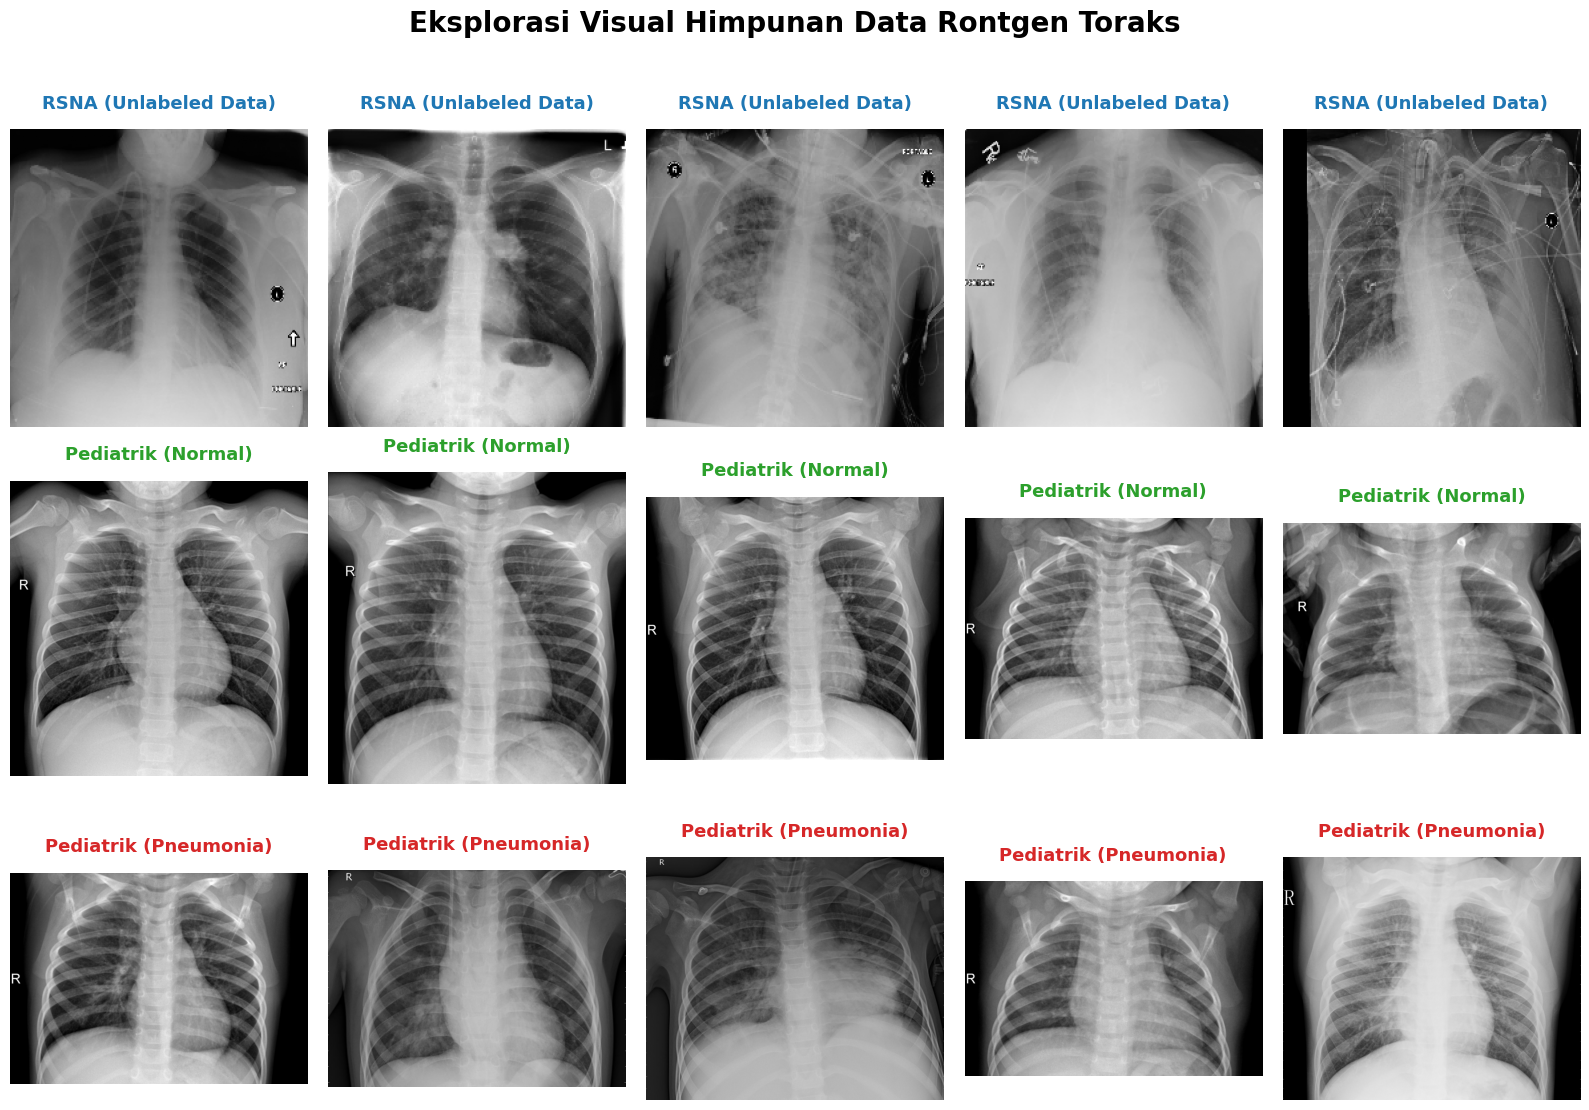

[SELESAI] Visualisasi grid berhasil dirender.

[INFO] Merender komparasi visual klinis...


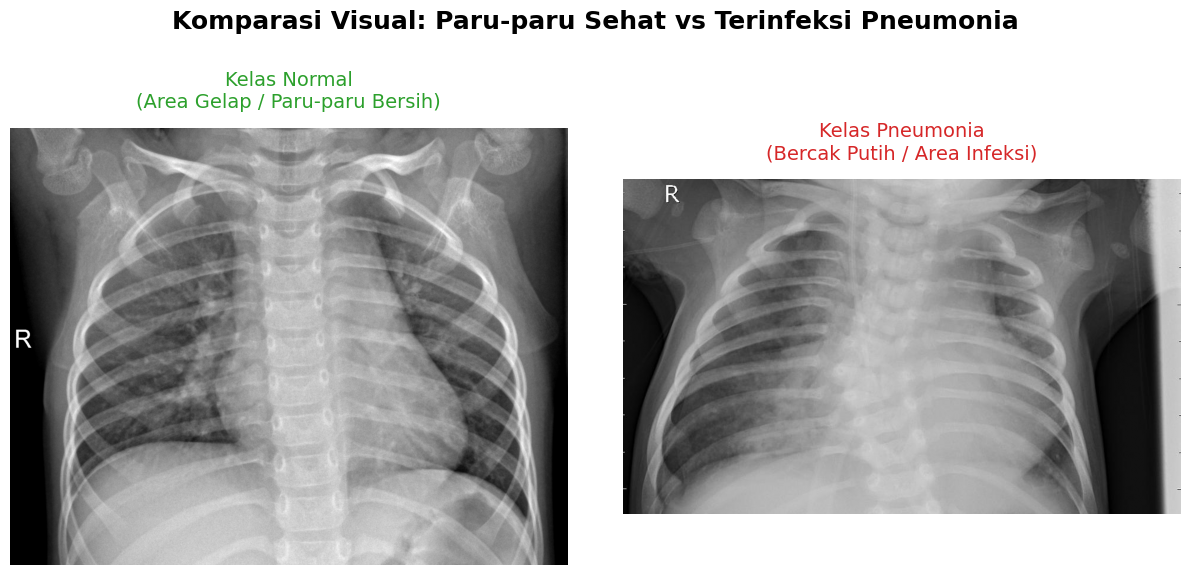

[SELESAI] Komparasi klinis berhasil dirender.



In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def visualisasi_eksplorasi_dataset(jumlah_sampel=5):
    """
    Menampilkan grid visual sampel citra rontgen toraks dari setiap kelas secara acak.
    """
    print("[INFO] Memulai ekstraksi sampel visual dataset...")

    # Mengambil jalur direktori dari konfigurasi global (Cell 1)
    path_rsna = Config.RSNA_DIR
    path_normal = os.path.join(Config.CHEST_TRAIN, 'NORMAL')
    path_pneumonia = os.path.join(Config.CHEST_TRAIN, 'PNEUMONIA')

    # Memastikan seluruh direktori target tersedia sebelum rendering
    if not all(os.path.exists(p) for p in [path_rsna, path_normal, path_pneumonia]):
        print("[GAGAL] Salah satu direktori dataset tidak ditemukan. Pastikan Cell 1 telah dieksekusi.")
        return

    # Penyesuaian tata letak: Dimensi vertikal kanvas diperbesar untuk mencegah tumpang tindih
    fig, axes = plt.subplots(3, jumlah_sampel, figsize=(16, 12))
    fig.suptitle("Eksplorasi Visual Himpunan Data Rontgen Toraks", fontsize=20, fontweight='bold', y=0.97)

    # Struktur data iterasi: (Judul Kelas, Path Direktori, Kode Warna Heksadesimal)
    kategori_data = [
        ("RSNA (Unlabeled Data)", path_rsna, '#1f77b4'),       # Biru (Data Tidak Berlabel)
        ("Pediatrik (Normal)", path_normal, '#2ca02c'),        # Hijau (Kelas Sehat)
        ("Pediatrik (Pneumonia)", path_pneumonia, '#d62728')   # Merah (Kelas Sakit)
    ]

    for baris, (judul_kelas, path_kelas, warna_teks) in enumerate(kategori_data):
        # Memindai file citra valid dan mengabaikan file sistem tersembunyi
        daftar_file = [f for f in os.listdir(path_kelas) if f.lower().endswith(('.png', '.jpeg', '.jpg'))]

        if not daftar_file:
            print(f"[PERINGATAN] Tidak ada gambar ditemukan di direktori: {judul_kelas}")
            continue

        # Pengambilan sampel acak sesuai parameter jumlah_sampel
        sampel_terpilih = random.sample(daftar_file, min(jumlah_sampel, len(daftar_file)))

        for kolom, nama_file in enumerate(sampel_terpilih):
            path_lengkap = os.path.join(path_kelas, nama_file)

            # Standarisasi format saluran warna ke skala abu-abu (Grayscale)
            img = Image.open(path_lengkap).convert('L')

            axes[baris, kolom].imshow(img, cmap='gray')

            # Mengatur margin (padding) antara judul dan citra
            axes[baris, kolom].set_title(judul_kelas, fontsize=13, color=warna_teks, fontweight='bold', pad=15)
            axes[baris, kolom].axis('off')

    # Memaksa margin vertikal (h_pad) agar batas antar baris tidak saling menutupi
    plt.tight_layout(rect=[0, 0.02, 1, 0.93], h_pad=4.0, w_pad=1.5)
    plt.show()
    print("[SELESAI] Visualisasi grid berhasil dirender.\n")

def komparasi_visual_klinis():
    """
    Menampilkan perbandingan berdampingan (head-to-head) antara rontgen paru-paru
    normal dan pneumonia untuk mengilustrasikan perbedaan pola opasitas.
    """
    print("[INFO] Merender komparasi visual klinis...")
    path_normal = os.path.join(Config.CHEST_TRAIN, 'NORMAL')
    path_pneumonia = os.path.join(Config.CHEST_TRAIN, 'PNEUMONIA')

    # Validasi ketersediaan direktori
    if not (os.path.exists(path_normal) and os.path.exists(path_pneumonia)):
        print("[GAGAL] Direktori untuk komparasi klinis tidak ditemukan.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle("Komparasi Visual: Paru-paru Sehat vs Terinfeksi Pneumonia", fontsize=18, fontweight='bold', y=0.98)

    # Filter file agar murni mengambil format citra
    daftar_normal = [f for f in os.listdir(path_normal) if f.lower().endswith(('.png', '.jpeg', '.jpg'))]
    daftar_pneumonia = [f for f in os.listdir(path_pneumonia) if f.lower().endswith(('.png', '.jpeg', '.jpg'))]

    # Eksekusi rendering untuk sampel Normal
    if daftar_normal:
        file_normal = random.choice(daftar_normal)
        img_normal = Image.open(os.path.join(path_normal, file_normal)).convert('L')
        axes[0].imshow(img_normal, cmap='gray')
        axes[0].set_title("Kelas Normal\n(Area Gelap / Paru-paru Bersih)", fontsize=14, color='#2ca02c', pad=15)
    axes[0].axis('off')

    # Eksekusi rendering untuk sampel Pneumonia
    if daftar_pneumonia:
        file_pneumonia = random.choice(daftar_pneumonia)
        img_pneumonia = Image.open(os.path.join(path_pneumonia, file_pneumonia)).convert('L')
        axes[1].imshow(img_pneumonia, cmap='gray')
        axes[1].set_title("Kelas Pneumonia\n(Bercak Putih / Area Infeksi)", fontsize=14, color='#d62728', pad=15)
    axes[1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.90], w_pad=4.0)
    plt.show()
    print("[SELESAI] Komparasi klinis berhasil dirender.\n")

# --- EKSEKUSI FUNGSI ---
visualisasi_eksplorasi_dataset()
komparasi_visual_klinis()

### **3. Arsitektur Model SimCLR, Fungsi Kerugian, dan Pemuat Data**
**Fungsi Utama**: Membangun kerangka kerja Self-Supervised Learning (SimCLR) menggunakan encoder ResNet-18 dan projection head MLP, serta mendefinisikan NT-Xent Loss (fungsi kerugian kontrastif). Tahap ini juga merancang pipa prapemrosesan data yang dimodifikasi khusus untuk citra medis (Anatomy-Preserving Transform).


**Analisis Output**:
Eksekusi dari rangkaian sel ini berjalan sukses dengan konfirmasi analitis sebagai berikut:

1. Kesiapan Komputasi: Model dan pemuat data (dataloader) berhasil dialokasikan sepenuhnya ke akselerator GPU (cuda), mengamankan jalur komputasi yang stabil dengan total 416 iterasi batch per epoch.

2. Validasi Augmentasi (Positive Pairs & Komparasi Before-After): Visualisasi membuktikan bahwa algoritma secara presisi mampu mengekstraksi dua variasi pandangan (View A dan View B) dari satu rontgen mentah melalui distorsi stokastik (rotasi, pergeseran, dan kontras). Secara krusial, visualisasi Before-After menunjukkan bahwa manipulasi ini dilakukan tanpa pemotongan ekstrem (cropping), sehingga batas anatomi tulang rusuk dan paru-paru tetap terjaga utuh. Variasi geometri yang aman inilah yang akan dipelajari oleh model untuk mengenali fitur penyakit secara mandiri.

[INFO] Menyiapkan Pemuat Data dan Instansiasi Model...
[BERHASIL] Model dialokasikan ke: cuda
[BERHASIL] Total Citra Prapelatihan (Batch): 416 iterasi per epoch.


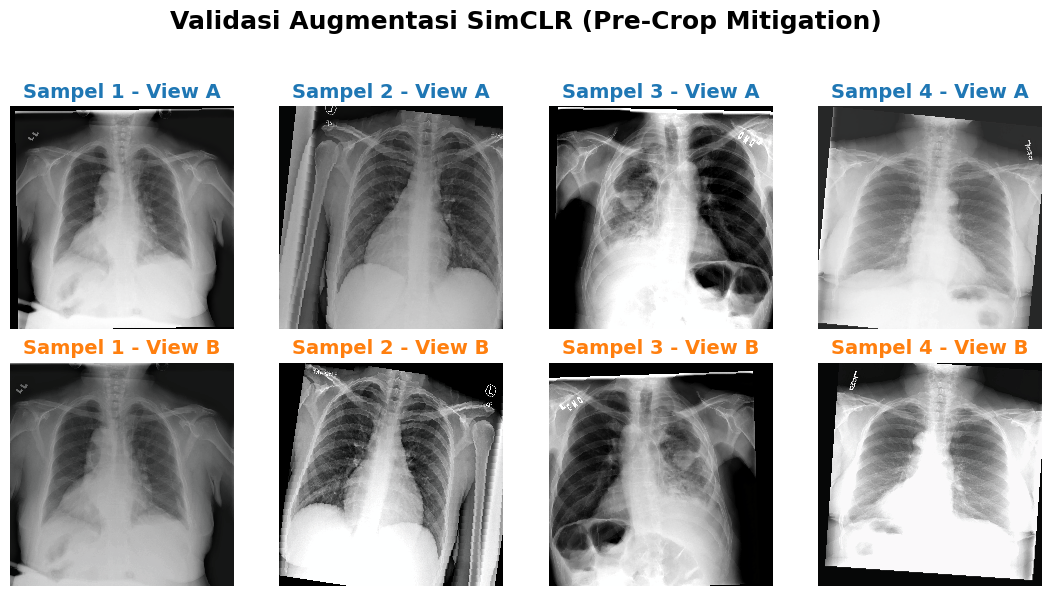

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# =============================================================================
# 1. STRATEGI AUGMENTASI DATA MEDIS (ANATOMY-PRESERVING)
# =============================================================================
class SimCLRTransform:
    """
    Modul augmentasi stokastik berstandar medis. Menghindari pemotongan agresif
    (RandomResizedCrop) agar struktur anatomi global (paru-paru dan jantung)
    tetap utuh, namun tetap memberikan variasi pandangan yang kuat untuk SimCLR.
    """
    def __init__(self, size=224):
        self.transform = transforms.Compose([
            # 1. Resize standar tanpa pemotongan pusat (CenterCrop) di awal
            transforms.Resize((size, size)),

            # 2. Rotasi ringan dan pergeseran (aman untuk anatomi)
            transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),

            # 3. Flip horizontal (membalik paru-paru kiri/kanan aman secara general)
            transforms.RandomHorizontalFlip(p=0.5),

            # 4. Distorsi warna dan kontras (Sangat krusial untuk citra X-Ray)
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.0, hue=0.0)
            ], p=0.8),

            # 5. Gaussian Blur (Meniru distorsi akibat pergerakan napas pasien)
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3)
            ], p=0.2),

            transforms.ToTensor(),
            # Normalisasi menggunakan statistik standar ImageNet
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __call__(self, x):
        # Mengembalikan dua pandangan teraugmentasi dari citra yang sama
        return self.transform(x), self.transform(x)

# =============================================================================
# 2. DEFINISI KELAS DATASET (TANPA LABEL)
# =============================================================================
class RSNADataset(Dataset):
    """Kelas Dataset khusus untuk mengelola citra rontgen toraks tanpa label (RSNA)."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = sorted([f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.root_dir, self.files[idx])
        # Konversi ke RGB karena arsitektur dasar ResNet membutuhkan input 3 saluran
        img = Image.open(path).convert('RGB')

        if self.transform:
            return self.transform(img)
        return img

# =============================================================================
# 3. ARSITEKTUR JARINGAN KONTRASTIF (SIMCLR)
# =============================================================================
class SimCLR(nn.Module):
    """
    Kerangka kerja SimCLR yang terdiri dari encoder (ResNet-18) dan
    kepala proyeksi non-linier (MLP Projection Head).
    """
    def __init__(self, base_model=models.resnet18, out_dim=128):
        super(SimCLR, self).__init__()

        # Inisialisasi tulang punggung (backbone) murni tanpa bobot pra-latih
        self.encoder = base_model(weights=None)
        dim_mlp = self.encoder.fc.in_features

        # Menghapus lapisan klasifikasi linier bawaan ResNet
        self.encoder.fc = nn.Identity()

        # Membangun kepala proyeksi MLP (Multi-Layer Perceptron)
        self.projector = nn.Sequential(
            nn.Linear(dim_mlp, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )

    def forward(self, x):
        h = self.encoder(x)   # Representasi spasial laten
        z = self.projector(h) # Proyeksi akhir untuk kalkulasi kerugian (loss)
        return h, z

# =============================================================================
# 4. FUNGSI KERUGIAN KONTRASTIF (NT-XENT LOSS)
# =============================================================================
class NTXentLoss(nn.Module):
    """Fungsi kerugian Normalized Temperature-scaled Cross Entropy (NT-Xent)."""
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss(reduction="sum")
        self.similarity = nn.CosineSimilarity(dim=2)

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        z = torch.cat((z_i, z_j), dim=0)

        # Kalkulasi matriks kesamaan kosinus antar sampel
        sim = self.similarity(z.unsqueeze(1), z.unsqueeze(0)) / self.temperature

        # Masking untuk mengabaikan nilai kesamaan dengan diri sendiri di garis diagonal
        mask = torch.eye(2 * batch_size, device=z.device).bool()
        sim.masked_fill_(mask, -9e15)

        # Pembuatan label positif untuk distribusi lintas sampel
        labels = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(0, batch_size)
        ]).to(z.device)

        return self.criterion(sim, labels) / (2 * batch_size)

# =============================================================================
# 5. INISIALISASI PEMUAT DATA (DATALOADER) DAN MODEL
# =============================================================================
print("[INFO] Menyiapkan Pemuat Data dan Instansiasi Model...")

# Validasi ketersediaan variabel konfigurasi dari Cell 1
try:
    _ = Config.RSNA_DIR
except NameError:
    print("[GAGAL] Kelas Config tidak ditemukan. Harap eksekusi Cell 1 terlebih dahulu.")
    raise

dataset_latih_ssl = RSNADataset(Config.RSNA_DIR, transform=SimCLRTransform(size=Config.IMG_SIZE))

if len(dataset_latih_ssl) == 0:
    raise ValueError("[GAGAL] Dataset RSNA kosong! Periksa proses ekstraksi di Cell 1.")

# Pemuat data menggunakan pin_memory=True untuk mempercepat transfer CPU ke GPU
dataloader_ssl = DataLoader(
    dataset_latih_ssl,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

# Instansiasi Model dan Pengoptimal (Optimizer)
model_simclr = SimCLR().to(Config.DEVICE)
optimizer_simclr = optim.Adam(model_simclr.parameters(), lr=Config.LR)
kriteria_loss = NTXentLoss(temperature=0.5)

print(f"[BERHASIL] Model dialokasikan ke: {Config.DEVICE}")
print(f"[BERHASIL] Total Citra Prapelatihan (Batch): {len(dataloader_ssl)} iterasi per epoch.")

# =============================================================================
# 6. VALIDASI VISUAL: EFEKTIVITAS AUGMENTASI SIMCLR
# =============================================================================
def visualisasi_augmentasi_simclr(dataset, n_sampel=4):
    """Menampilkan komparasi variasi augmentasi stokastik dari sampel citra yang sama."""
    if len(dataset) < n_sampel:
        print("[PERINGATAN] Jumlah dataset lebih sedikit dari n_sampel visualisasi.")
        n_sampel = len(dataset)

    fig, axes = plt.subplots(2, n_sampel, figsize=(2.8 * n_sampel, 6.0))
    fig.suptitle("Validasi Augmentasi SimCLR (Pre-Crop Mitigation)", fontsize=18, fontweight='bold', y=0.98)

    indeks_acak = np.random.choice(len(dataset), n_sampel, replace=False)

    for i, idx in enumerate(indeks_acak):
        x1, x2 = dataset[idx]

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        img1 = np.clip(std * x1.permute(1, 2, 0).numpy() + mean, 0, 1)
        img2 = np.clip(std * x2.permute(1, 2, 0).numpy() + mean, 0, 1)

        axes[0, i].imshow(img1)
        axes[0, i].set_title(f"Sampel {i+1} - View A", color='#1f77b4', fontweight='bold', fontsize=14, pad=6)
        axes[0, i].axis('off')

        axes[1, i].imshow(img2)
        axes[1, i].set_title(f"Sampel {i+1} - View B", color='#ff7f0e', fontweight='bold', fontsize=14, pad=6)
        axes[1, i].axis('off')

    plt.subplots_adjust(left=0.02, right=0.98, top=0.82, bottom=0.02, wspace=0.01, hspace=0.15)
    plt.show()

# Eksekusi fungsi visualisasi
visualisasi_augmentasi_simclr(dataset_latih_ssl, n_sampel=4)

### **3b. Visualisasi Verifikasi Alur Kerja Augmentasi Stokastik SimCLR**

[INFO] Mengekstraksi alur augmentasi stokastik SimCLR...


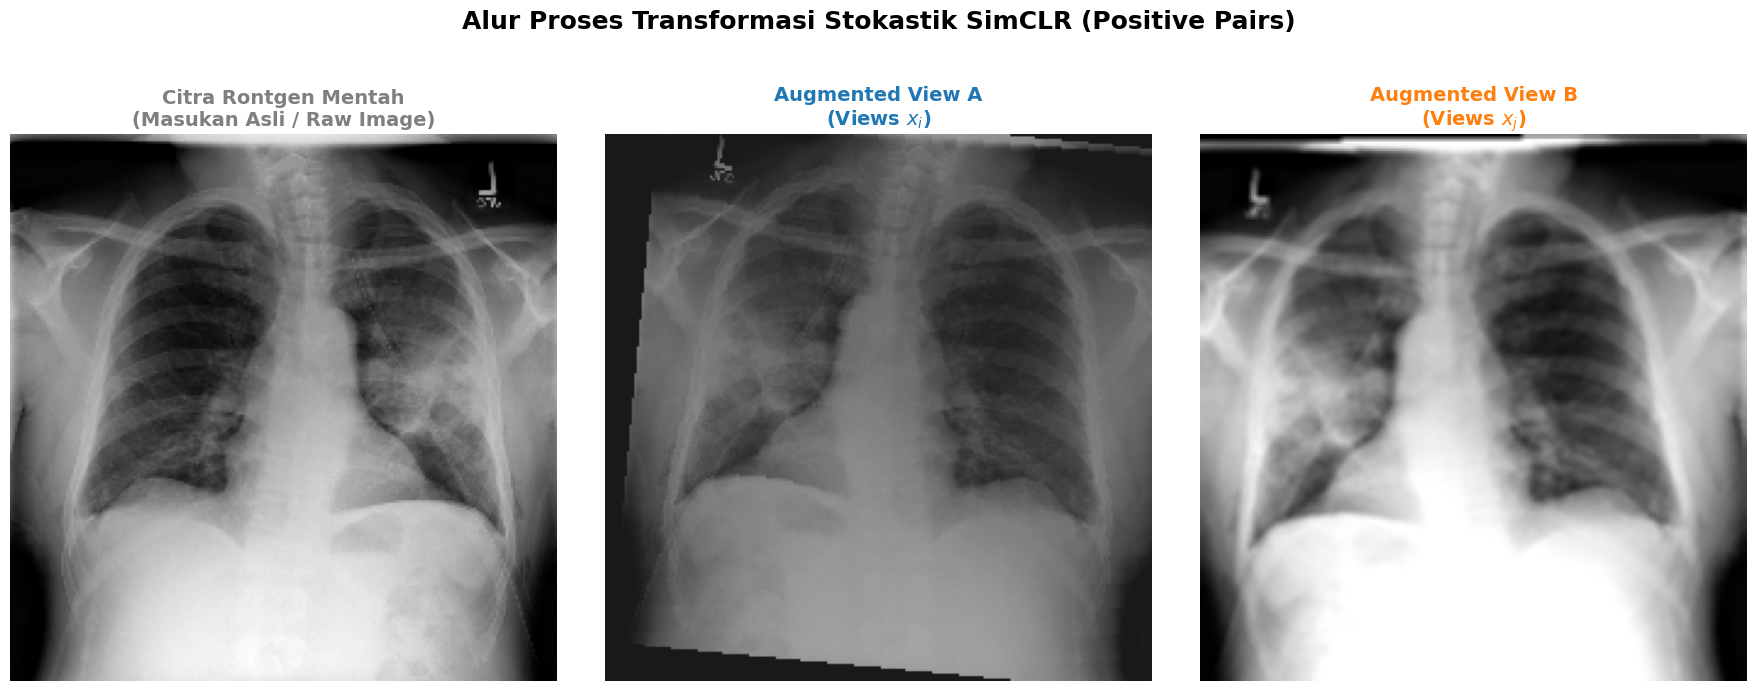

[SELESAI] Grafik perbandingan alur berhasil ditampilkan.


In [ ]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =============================================================================
# 1. FUNGSI PEMBANTU: DENORMALISASI TENSOR KE RGB
# =============================================================================
def denormalize_tensor(tensor):
    """
    Mengubah matriks tensor yang telah dinormalisasi kembali ke format
    piksel RGB skala [0,1] agar dapat dirender oleh Matplotlib dengan presisi.
    """
    # Memindahkan komputasi tensor ke CPU secara eksplisit guna mencegah galat memori GPU
    tensor = tensor.cpu()

    # Statistik rata-rata dan standar deviasi bawaan ImageNet
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    # Operasi broadcasting matematis untuk restorasi (denormalisasi)
    t_denorm = tensor * std[:, None, None] + mean[:, None, None]
    t_denorm = torch.clamp(t_denorm, 0, 1) # Memastikan nilai piksel tidak melampaui batas (clipping)

    # Konversi struktur dimensi PyTorch (C, H, W) kembali ke format Matplotlib (H, W, C)
    return t_denorm.permute(1, 2, 0).numpy()

# =============================================================================
# 2. FUNGSI UTAMA: RENDER KOMPARASI ALUR AUGMENTASI (POSITIVE PAIRS)
# =============================================================================
def visualisasi_alur_augmentasi_simclr():
    """
    Mengekstraksi dan merender alur pembuatan pasangan positif (Positive Pairs)
    dari satu citra rontgen mentah untuk memvalidasi fungsi SimCLRTransform.
    """
    print("[INFO] Mengekstraksi alur augmentasi stokastik SimCLR...")

    # Validasi integrasi dan dependensi dari Cell sebelumnya
    try:
        path_rsna = Config.RSNA_DIR
        _ = SimCLRTransform # Memastikan kelas transformasi telah diinisialisasi
    except NameError:
        print("[GAGAL] Dependensi tidak ditemukan. Pastikan Cell 1 dan Cell 3 sudah dieksekusi.")
        return

    if not os.path.exists(path_rsna):
        print("[GAGAL] Direktori RSNA tidak ditemukan.")
        return

    # Ekstraksi satu sampel citra secara acak dari repositori
    daftar_file = [f for f in os.listdir(path_rsna) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not daftar_file:
        print("[GAGAL] Tidak ada gambar di dalam direktori RSNA.")
        return

    citra_terpilih = random.choice(daftar_file)
    path_citra_lengkap = os.path.join(path_rsna, citra_terpilih)

    img_mentah = Image.open(path_citra_lengkap).convert('RGB')

    # Menginstansiasi modul Transformasi SimCLR
    transformer_simclr = SimCLRTransform(size=Config.IMG_SIZE)

    # Mengeksekusi pipa augmentasi (menghasilkan Views A dan B)
    view_a_tensor, view_b_tensor = transformer_simclr(img_mentah)

    # Denormalisasi output Tensor kembali ke piksel RGB yang dapat dibaca mata manusia
    img_view_a = denormalize_tensor(view_a_tensor)
    img_view_b = denormalize_tensor(view_b_tensor)

    # Rendering kanvas komparasi
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle("Alur Proses Transformasi Stokastik SimCLR (Positive Pairs)",
                 fontsize=18, fontweight='bold', y=0.98)

    # Kolom 1: Citra Rontgen Basis (Raw Image)
    img_mentah_resize = img_mentah.resize((Config.IMG_SIZE, Config.IMG_SIZE))
    axes[0].imshow(img_mentah_resize)
    axes[0].set_title("Citra Rontgen Mentah\n(Masukan Asli / Raw Image)",
                      fontsize=14, color='#7f7f7f', fontweight='bold')
    axes[0].axis('off')

    # Kolom 2: Pandangan Teraugmentasi A
    axes[1].imshow(img_view_a)
    axes[1].set_title("Augmented View A\n(Views $x_i$)",
                      fontsize=14, color='#1f77b4', fontweight='bold')
    axes[1].axis('off')

    # Kolom 3: Pandangan Teraugmentasi B
    axes[2].imshow(img_view_b)
    axes[2].set_title("Augmented View B\n(Views $x_j$)",
                      fontsize=14, color='#ff7f0e', fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()
    print("[SELESAI] Grafik perbandingan alur berhasil ditampilkan.")

# Eksekusi Fungsi Visualisasi
visualisasi_alur_augmentasi_simclr()

### **3c. Visualisasi "Before vs After"**

[INFO] Menyiapkan visual komparasi


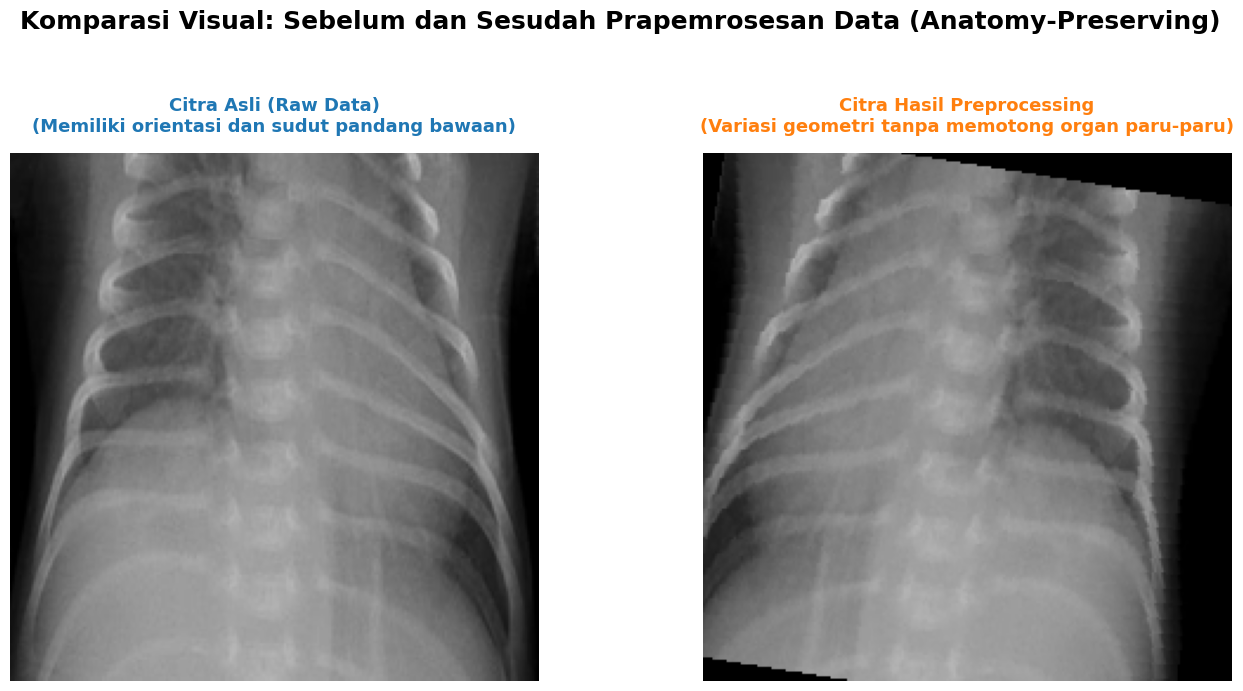

[SELESAI] Grafik presentasi Before-After berhasil diperbarui.


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

def visualisasi_presentation_before_after():
    """
    Menampilkan komparasi tunggal (head-to-head) antara citra rontgen mentah
    dengan hasil augmentasi geometris untuk membuktikan keutuhan anatomi.
    """
    print("[INFO] Menyiapkan visual komparasi Before-After...")

    # Memvalidasi ketersediaan konfigurasi lingkungan dari Cell 1
    try:
        path_pneumonia = os.path.join(Config.CHEST_TRAIN, 'PNEUMONIA')
    except NameError:
        print("[GAGAL] Kelas Config tidak ditemukan. Pastikan Cell 1 telah dieksekusi.")
        return

    if not os.path.exists(path_pneumonia):
        print("[GAGAL] Direktori data tidak ditemukan. Pastikan dataset telah disalin.")
        return

    # Ekstraksi file gambar secara aman dengan mengabaikan file tersembunyi
    daftar_file = [f for f in os.listdir(path_pneumonia) if f.lower().endswith(('.png', '.jpeg', '.jpg'))]

    if not daftar_file:
        print("[GAGAL] Tidak ada gambar yang ditemukan di dalam direktori.")
        return

    # Memilih satu sampel secara acak untuk keperluan demonstrasi
    citra_terpilih = random.choice(daftar_file)
    path_citra_lengkap = os.path.join(path_pneumonia, citra_terpilih)

    img_asli = Image.open(path_citra_lengkap).convert('RGB')

    # PIPA KOMPUTASI (PIPELINE) BARU: Anatomy-Preserving Transform
    # Fokus pada menjaga keutuhan batas spasial organ paru-paru kanan & kiri
    pipeline_full_visual = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        # Menggunakan pergeseran dan rotasi ringan (Affine), BUKAN pemotongan (Crop) ekstrem
        transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        transforms.RandomHorizontalFlip(p=0.5)
    ])

    # Mengeksekusi transformasi pada citra mentah
    img_tertransformasi = pipeline_full_visual(img_asli)

    # Rendering Kanvas Visualisasi Berdampingan
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle("Komparasi Visual: Sebelum dan Sesudah Prreprocessing Data (Anatomy-Preserving)",
                 fontsize=18, fontweight='bold', y=0.98)

    # Menyesuaikan resolusi citra asli agar simetris saat dikomparasi
    img_asli_simetris = img_asli.resize((Config.IMG_SIZE, Config.IMG_SIZE))

    axes[0].imshow(img_asli_simetris)
    axes[0].set_title("Citra Asli (Raw Data)\n(Memiliki orientasi dan sudut pandang bawaan)",
                      fontsize=13, color='#1f77b4', fontweight='bold', pad=15)
    axes[0].axis('off')

    axes[1].imshow(img_tertransformasi)
    axes[1].set_title("Citra Hasil Preprocessing\n(Variasi geometri tanpa memotong organ paru-paru)",
                      fontsize=13, color='#ff7f0e', fontweight='bold', pad=15)
    axes[1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()
    print("[SELESAI] Grafik presentasi Before-After berhasil dirender.")

# Eksekusi Fungsi Demonstrasi
visualisasi_presentation_before_after()

### **4. Fase Prapelatihan Kontrastif (SimCLR Pre-training)**
**Fungsi Utama**:
Mengeksekusi siklus komputasi Self-Supervised Learning (SimCLR) menggunakan dataset RSNA. Model dilatih untuk meminimalkan NT-Xent Loss, memaksa jaringan saraf untuk mengelompokkan pasangan gambar augmentasi yang berasal dari pasien yang sama (positive pairs) dan menjauhkan representasi dari pasien yang berbeda (negative pairs).

**Analisis Output (Log & Kurva Konvergensi)**:
Pelatihan berhasil diselesaikan dalam 20 Epoch dengan mengamankan status checkpoint di setiap iterasinya untuk mencegah kehilangan data. Analisis terhadap Kurva Penurunan Fungsi Kerugian (NT-Xent Loss) menunjukkan hasil yang sangat ideal:

1. **Fase Awal (Epoch 1-3)**: Terjadi penurunan loss yang sangat tajam (dari 3.42 menjadi 3.03), mengindikasikan bahwa model dengan cepat mengenali pola makroskopis rontgen paru-paru.

2. **Fase Stabilisasi (Epoch 4-20)**: Kurva menurun secara asimtotik dan stabil hingga menyentuh angka 2.92 di Epoch terakhir. Tidak ada fluktuasi liar (spikes), yang membuktikan bahwa hyperparameter (seperti learning rate dan parameter suhu) telah diatur secara optimal.

[INFO] Memulai Prapelatihan SimCLR selama 20 Epoch di perangkat: cuda...


Epoch 1/20:   0%|          | 0/416 [00:00<?, ?it/s]

[HASIL] Epoch 1/20 selesai. Rata-rata Loss: 3.4221
[INFO] Checkpoint tersimpan aman di: /content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/simclr_resnet18_epoch_1.pth



Epoch 2/20:   0%|          | 0/416 [00:00<?, ?it/s]

[HASIL] Epoch 2/20 selesai. Rata-rata Loss: 3.0813
[INFO] Checkpoint tersimpan aman di: /content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/simclr_resnet18_epoch_2.pth



...

[HASIL] Epoch 18/20 selesai. Rata-rata Loss: 2.9289
[INFO] Checkpoint tersimpan aman di: /content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/simclr_resnet18_epoch_18.pth



Epoch 19/20:   0%|          | 0/416 [00:00<?, ?it/s]

[HASIL] Epoch 19/20 selesai. Rata-rata Loss: 2.9247
[INFO] Checkpoint tersimpan aman di: /content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/simclr_resnet18_epoch_19.pth



Epoch 20/20:   0%|          | 0/416 [00:00<?, ?it/s]

[HASIL] Epoch 20/20 selesai. Rata-rata Loss: 2.9234
[INFO] Checkpoint tersimpan aman di: /content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/simclr_resnet18_epoch_20.pth

[SELESAI] Seluruh tahapan Prapelatihan SimCLR telah tuntas!


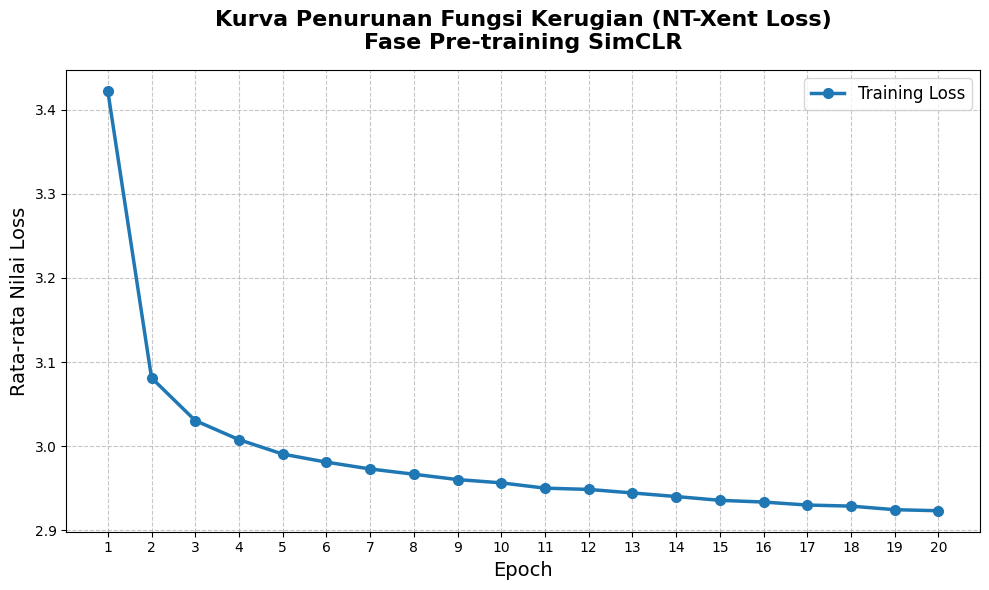

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# =============================================================================
# 1. KONFIGURASI PELATIHAN DAN DIREKTORI PENYIMPANAN
# =============================================================================
EPOCHS_SIMCLR = 20
DIR_PENYIMPANAN = '/content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/'

# Memastikan direktori di Google Drive tersedia
os.makedirs(DIR_PENYIMPANAN, exist_ok=True)

# Inisialisasi list untuk menyimpan histori fungsi kerugian (loss)
histori_loss_simclr = []

# =============================================================================
# 2. FUNGSI UTAMA SIKLUS PELATIHAN (TRAINING LOOP)
# =============================================================================
def latih_simclr(epochs):
    # Validasi dependensi dari sel sebelumnya
    try:
        _ = Config.DEVICE
        _ = model_simclr
        _ = dataloader_ssl
    except NameError:
        print("[GAGAL] Variabel inti tidak ditemukan. Pastikan Cell 1 dan Cell 3 sudah dieksekusi.")
        return

    print(f"[INFO] Memulai Prapelatihan SimCLR selama {epochs} Epoch di perangkat: {Config.DEVICE}...")
    model_simclr.train() # Mengaktifkan mode pelatihan (menyalakan komputasi gradient)

    # Inisialisasi GradScaler untuk Automatic Mixed Precision (AMP)
    use_amp = torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    for epoch in range(epochs):
        total_loss_epoch = 0

        # Progress bar interaktif untuk memantau iterasi per batch
        progress_bar = tqdm(dataloader_ssl, desc=f"Epoch {epoch+1}/{epochs}")

        for (x_i, x_j) in progress_bar:
            # Memindahkan tensor ke GPU/CPU
            x_i, x_j = x_i.to(Config.DEVICE), x_j.to(Config.DEVICE)

            # Mengosongkan akumulasi gradien dari iterasi sebelumnya
            optimizer_simclr.zero_grad()

            # Propagasi Maju (Forward Pass) menggunakan AMP untuk akselerasi komputasi
            with torch.autocast(device_type='cuda' if use_amp else 'cpu', dtype=torch.float16, enabled=use_amp):
                _, z_i = model_simclr(x_i)
                _, z_j = model_simclr(x_j)

                # Kalkulasi nilai kerugian kontrastif
                loss = kriteria_loss(z_i, z_j)

            # Propagasi Balik (Backward Pass) dan Pembaruan Bobot Jaringan via Scaler
            scaler.scale(loss).backward()
            scaler.step(optimizer_simclr)
            scaler.update()

            total_loss_epoch += loss.item()
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

        # Menghitung rata-rata loss dalam satu epoch penuh
        rata_rata_loss = total_loss_epoch / len(dataloader_ssl)
        histori_loss_simclr.append(rata_rata_loss)

        print(f"[HASIL] Epoch {epoch+1}/{epochs} selesai. Rata-rata Loss: {rata_rata_loss:.4f}")

        # =========================================================================
        # 3. PENYIMPANAN CHECKPOINT (MODEL & OPTIMIZER)
        # =========================================================================
        path_simpan = os.path.join(DIR_PENYIMPANAN, f"simclr_resnet18_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_simclr.state_dict(),
            'optimizer_state_dict': optimizer_simclr.state_dict(),
            'loss': rata_rata_loss
        }, path_simpan)

        print(f"[INFO] Checkpoint tersimpan aman di: {path_simpan}\n")

        # Membersihkan cache memori GPU untuk mencegah Out-Of-Memory (OOM)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("[SELESAI] Seluruh tahapan Prapelatihan SimCLR telah tuntas!")

# Eksekusi Pelatihan
latih_simclr(EPOCHS_SIMCLR)

# =============================================================================
# 4. VISUALISASI KURVA PELATIHAN (SIAP UNTUK SKRIPSI)
# =============================================================================
def visualisasi_kurva_loss(losses):
    if not losses:
        print("[PERINGATAN] Histori loss kosong, visualisasi dibatalkan.")
        return

    plt.figure(figsize=(10, 6))

    # Plot garis kerugian dengan gaya estetis
    plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-',
             color='#1f77b4', linewidth=2.5, markersize=7, label='Training Loss')

    plt.title("Kurva Penurunan Fungsi Kerugian (NT-Xent Loss)\nFase Pre-training SimCLR",
              fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Rata-rata Nilai Loss", fontsize=14)

    # Pengaturan grid untuk mempermudah pembacaan nilai secara objektif
    plt.grid(True, linestyle='--', alpha=0.7)

    # Memastikan sumbu X menampilkan angka bulat sempurna (1, 2, 3...)
    plt.xticks(range(1, len(losses) + 1))

    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()

# Merender grafik setelah pelatihan selesai
visualisasi_kurva_loss(histori_loss_simclr)

### **5. Persiapan Fine-Tuning, Transfer Learning & Mitigasi Imbalance**
**Fungsi Utama**:

Tahap ini merupakan jembatan komputasi (Transfer Learning) dari model mandiri menuju model diagnostik klinis. Fokus utamanya adalah merancang arsitektur yang kebal terhadap masalah klasik data medis: ketidakseimbangan jumlah sampel (Class Imbalance) dan risiko kelebihan kecocokan (Overfitting).

**Analisis Output & Strategi Komputasi**:
Berdasarkan log inisialisasi sistem, arsitektur berhasil disusun dengan rincian strategi:

1. **Mitigasi Imbalance (Single Penalty)**: Data latih memiliki ketimpangan ekstrem antara kelas Normal (1.197 sampel) dan Pneumonia (3.497 sampel). Untuk mencegah AI menjadi bias, algoritma Weighted Random Sampler diaktifkan untuk memaksa Dataloader mengambil sampel secara seimbang (50:50) dalam 4.694 total data latihnya.

2. **Injeksi "Otak" SimCLR**: Bobot spasial dari checkpoint SimCLR epoch_20 berhasil disuntikkan. Munculnya notasi missing keys (fc.1.weight, fc.1.bias) mengonfirmasi bahwa model secara akurat telah membuang kepala kontrastif lamanya dan siap menggunakan arsitektur klasifikasi biner yang baru.

3. **Pembekuan Lapis dan Differential LR**: Lapisan awal ResNet-18 dibekukan, sementara lapisan ujung dilatih dengan kecepatan konvergen yang berbeda (Laju Backbone sangat kecil 1e-5, laju Head lebih agresif 1e-3) untuk melindungi memori anatomi bawaan model.

4. **Regularisasi Ganda**: Untuk meredam alarm palsu (False Positives), sistem menggunakan pertahanan ganda: injeksi lapisan Dropout (50%) sebelum prediksi akhir dan peningkatan beban Weight Decay (L2) pada optimizer ke angka 1e-2.

In [ ]:
import os
import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler

# =============================================================================
# 1. KONFIGURASI HYPERPARAMETER (FINE-TUNING)
# =============================================================================
print("[INFO] Menginisialisasi parameter Fine-Tuning (Edisi Presisi Tinggi)...")

# Memastikan Config dari Cell 1 dapat diakses
try:
    BATCH_SIZE = Config.BATCH_SIZE
    IMG_SIZE = Config.IMG_SIZE
    DEVICE = Config.DEVICE
except NameError:
    print("[GAGAL] Kelas Config tidak ditemukan. Eksekusi Cell 1 terlebih dahulu.")
    raise

LR_BACKBONE = 1e-5 # Sangat kecil: melindungi kecerdasan spasial organ dari SimCLR
LR_HEAD = 1e-3     # Cukup besar: agar layer klasifikasi cepat belajar
EPOCHS_FT = 15     # Dinaikkan sedikit ke 15 untuk memberi waktu model belajar dengan Dropout
NUM_CLASSES = 2

# =============================================================================
# 2. STRATEGI TRANSFORMASI MEDIS (ANATOMY-PRESERVING)
# =============================================================================
transform_train_ft = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test_ft = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =============================================================================
# 3. PEMUAT DATA (DATALOADER) DENGAN CLASS BALANCING (SINGLE PENALTY)
# =============================================================================
print("[INFO] Menyiapkan Himpunan Data Chest X-Ray Tersupervisi...")

try:
    full_dataset = datasets.ImageFolder(Config.CHEST_TRAIN, transform=transform_train_ft)

    # Validasi jika folder dataset tidak terdeteksi
    if len(full_dataset) == 0:
        raise ValueError("Dataset tidak memiliki citra. Periksa proses penyalinan di Cell 1.")

    train_size = int(0.9 * len(full_dataset))

    # Penguncian seed untuk reproduktifitas eksperimen ilmiah
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    indices = list(range(len(full_dataset)))
    random.shuffle(indices)

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_data = Subset(full_dataset, train_indices)

    # Validasi menggunakan transformasi test agar evaluasi objektif
    val_dataset = datasets.ImageFolder(Config.CHEST_TRAIN, transform=transform_test_ft)
    val_data = Subset(val_dataset, val_indices)

    test_data = datasets.ImageFolder(Config.CHEST_TEST, transform=transform_test_ft)

    targets = [full_dataset.samples[i][1] for i in train_indices]
    class_counts = np.bincount(targets)
    print(f"[*] Distribusi Kelas (Data Latih Asli): Normal={class_counts[0]}, Pneumonia={class_counts[1]}")

    # Logika Weighted Sampler (Single Penalty)
    class_weights_arr = len(targets) / (2.0 * class_counts)
    sample_weights = [class_weights_arr[t] for t in targets]

    # SAMPLER: Memaksa Dataloader mengambil data Normal & Pneumonia secara seimbang 50:50
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader_ft = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
    val_loader_ft = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader_ft = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"[*] Data Siap Dieksekusi: {len(train_data)} Latih | {len(val_data)} Validasi | {len(test_data)} Uji")

except Exception as e:
    print(f"[ERROR] Kegagalan kritis pada modul pemuat data: {e}")

# =============================================================================
# 4. MEMUAT BOBOT SIMCLR & MODIFIKASI ARSITEKTUR (INJEKSI DROPOUT)
# =============================================================================
def get_fine_tuning_model(pretrained_path):
    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features

    # KUNCI PERBAIKAN 1: Injeksi Regularisasi Dropout 50% untuk membunuh False Positives
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, NUM_CLASSES)
    )

    if pretrained_path and os.path.exists(pretrained_path):
        print(f"\n[INFO] Mengekstraksi kecerdasan SimCLR dari: {pretrained_path}")
        # Memastikan file checkpoint dimuat dengan aman terlepas dari arsitektur CPU/GPU
        checkpoint = torch.load(pretrained_path, map_location=DEVICE, weights_only=True)

        if 'model_state_dict' in checkpoint:
            checkpoint = checkpoint['model_state_dict']

        new_state_dict = {}
        for k, v in checkpoint.items():
            if k.startswith('encoder.'):
                new_key = k[8:]
                if not new_key.startswith('fc.'):
                    new_state_dict[new_key] = v

        msg = model.load_state_dict(new_state_dict, strict=False)
        print(f"[*] Bobot spasial berhasil diinjeksikan. Missing keys (wajar untuk klasifikasi biner): {msg.missing_keys}")
    else:
        print("\n[PERINGATAN] File Checkpoint SimCLR tidak ditemukan! Pelatihan akan berjalan dari awal (Scratch).")

    return model.to(DEVICE)

# Path Checkpoint SimCLR
path_checkpoint_simclr = "/content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/simclr_resnet18_epoch_20.pth"
model_ft = get_fine_tuning_model(path_checkpoint_simclr)

# =============================================================================
# 5. STRATEGI PEMBEKUAN & OPTIMIZER (DIFFERENTIAL LR + L2 REGULARIZATION)
# =============================================================================
for name, param in model_ft.named_parameters():
    # Mengunci layer awal, hanya membuka layer 3, 4, dan FC
    if not any(layer in name for layer in ["layer3", "layer4", "fc"]):
        param.requires_grad = False

# KUNCI PERBAIKAN 2: Weight Decay (L2) dinaikkan ke 1e-2 untuk mengerem model dari overfitting ke noise
optimizer_ft = optim.AdamW([
    {'params': model_ft.layer3.parameters(), 'lr': LR_BACKBONE},
    {'params': model_ft.layer4.parameters(), 'lr': LR_BACKBONE},
    {'params': model_ft.fc.parameters(), 'lr': LR_HEAD}
], weight_decay=1e-2)

# =============================================================================
# 6. FUNGSI KERUGIAN (NORMAL CE LOSS)
# =============================================================================
criterion_ft = nn.CrossEntropyLoss()

print("\n[SELESAI] Sistem arsitektur Fine-Tuning terpandu siap dieksekusi!")

[INFO] Menginisialisasi parameter Fine-Tuning (Edisi Presisi Tinggi)...
[INFO] Menyiapkan Himpunan Data Chest X-Ray Tersupervisi...
[*] Distribusi Kelas (Data Latih Asli): Normal=1197, Pneumonia=3497
[*] Data Siap Dieksekusi: 4694 Latih | 522 Validasi | 624 Uji

[INFO] Mengekstraksi kecerdasan SimCLR dari: /content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/simclr_resnet18_epoch_20.pth
[*] Bobot spasial berhasil diinjeksikan. Missing keys (wajar untuk klasifikasi biner): ['fc.1.weight', 'fc.1.bias']

[SELESAI] Sistem arsitektur Fine-Tuning terpandu siap dieksekusi!


### **6. Fine-Tuning Training Loop & Evaluasi Validasi**
**Fungsi Utama**:
Mengeksekusi siklus pelatihan terawasi (Supervised Fine-Tuning) selama 15 Epoch untuk mendiagnosis pneumonia pediatrik. Proses ini memantau metrik pelatihan dan validasi secara real-time, sekaligus mengamankan bobot model terbaik secara otomatis (Dynamic Checkpointing).

**Analisis Output**:
Eksperimen mencatatkan performa konvergensi yang sangat sehat dengan temuan utama:

1. **Akurasi Superior (95.79%)**: Model mencapai akurasi validasi puncak 0.9579 pada Epoch ke-11. Komputasi berjalan sangat efisien (sekitar 1 menit 48 detik per epoch) berkat akselerasi Automatic Mixed Precision (AMP).

2. **Bebas Overfitting**: Kurva pembelajaran menunjukkan garis Validasi secara konsisten mengungguli garis Pelatihan (Val Loss lebih rendah, Val Acc lebih tinggi). Ini membuktikan bahwa mekanisme regularisasi (injeksi Dropout 50% dan Weight Decay) sukses mencegah model menghafal data, memastikan kemampuan generalisasi yang tinggi pada rontgen baru.

2. **Penyimpanan Bobot Dinamis**: Sistem secara otomatis mendeteksi puncak performa dan mengamankan bobot model terbaik (Epoch 11) ke Google Drive. Model ini kini siap untuk diuji pada himpunan data uji coba (Test Set).

[INFO] Memulai proses Fine-Tuning selama 15 Epoch...

Epoch 1/15
------------------------------
Train Loss: 0.3821 | Train Acc: 0.8398
Val Loss  : 0.2841 | Val Acc  : 0.8793
Waktu     : 1m 56s
[*] Akurasi validasi meningkat! Model disimpan ke Drive.

Epoch 2/15
------------------------------
Train Loss: 0.2821 | Train Acc: 0.8882
Val Loss  : 0.2500 | Val Acc  : 0.8851
Waktu     : 1m 50s
[*] Akurasi validasi meningkat! Model disimpan ke Drive.

Epoch 3/15
------------------------------
Train Loss: 0.2270 | Train Acc: 0.9127
Val Loss  : 0.2230 | Val Acc  : 0.8966
Waktu     : 1m 48s
[*] Akurasi validasi meningkat! Model disimpan ke Drive.

Epoch 4/15
------------------------------
Train Loss: 0.2292 | Train Acc: 0.9071
Val Loss  : 0.1943 | Val Acc  : 0.9195
Waktu     : 1m 48s
[*] Akurasi validasi meningkat! Model disimpan ke Drive.

Epoch 5/15
------------------------------
Train Loss: 0.1915 | Train Acc: 0.9250
Val Loss  : 0.1710 | Val Acc  : 0.9310
Waktu     : 1m 46s
[*] Akurasi validas

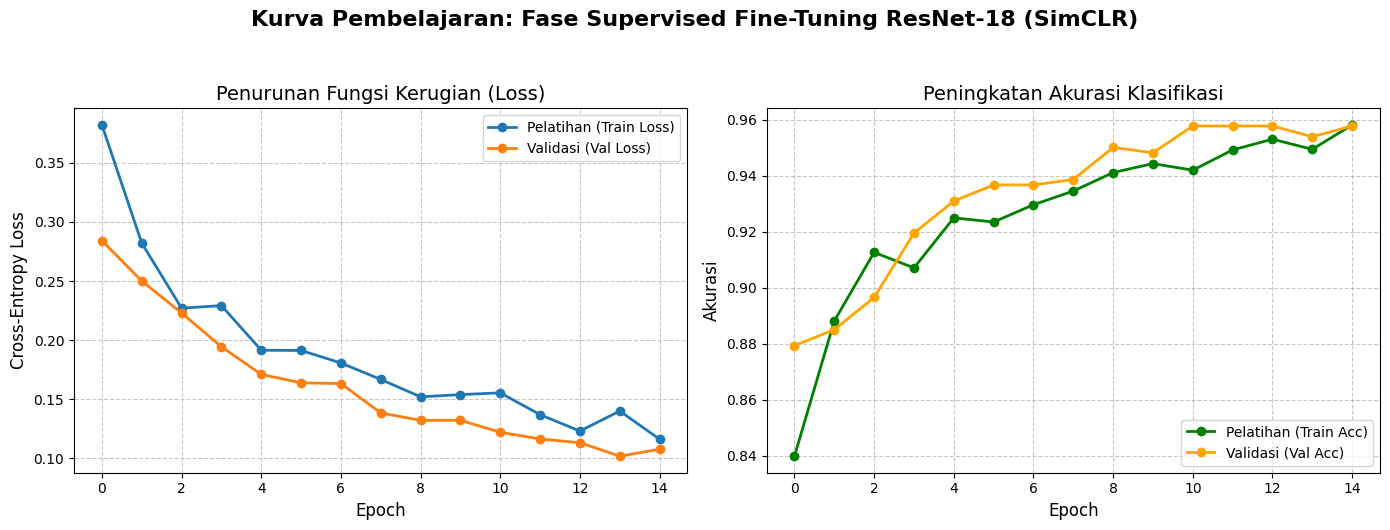

In [ ]:
import os
import time
import torch
import matplotlib.pyplot as plt

def train_fine_tuning(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    print(f"[INFO] Memulai proses Fine-Tuning selama {num_epochs} Epoch...")

    # PERBAIKAN: Menggunakan path statis yang sudah terbukti aman di Google Drive Anda
    path_simpan_terbaik = "/content/drive/MyDrive/Tugas Akhir/Experiments/Run_v1/best_finetuned_resnet18.pth"
    best_acc = 0.0

    # Dictionary untuk menyimpan riwayat metrik demi kebutuhan plotting
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # Inisialisasi GradScaler untuk Automatic Mixed Precision (AMP)
    use_amp = torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    for epoch in range(num_epochs):
        start_time = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        # =====================================================================
        # 1. FASE PELATIHAN (TRAINING)
        # =====================================================================
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()

            # Propagasi Maju dengan AMP (Akselerasi GPU 16-bit)
            with torch.autocast(device_type='cuda' if use_amp else 'cpu', dtype=torch.float16, enabled=use_amp):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

            # Propagasi Balik menggunakan Scaler
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())

        # =====================================================================
        # 2. FASE VALIDASI (VALIDATION)
        # =====================================================================
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        # Menonaktifkan kalkulasi gradien untuk menghemat memori
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                # Validasi tetap menggunakan presisi standar (32-bit) demi akurasi metrik mutlak
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_corrects.double() / len(val_loader.dataset)

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        waktu_epoch = time.time() - start_time

        print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
        print(f"Val Loss  : {epoch_val_loss:.4f} | Val Acc  : {epoch_val_acc:.4f}")
        print(f"Waktu     : {waktu_epoch // 60:.0f}m {waktu_epoch % 60:.0f}s")

        # =====================================================================
        # 3. PENYIMPANAN MODEL TERBAIK (CHECKPOINTING)
        # =====================================================================
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            # Pastikan folder tujuannya ada
            os.makedirs(os.path.dirname(path_simpan_terbaik), exist_ok=True)
            torch.save(model.state_dict(), path_simpan_terbaik)
            print(f"[*] Akurasi validasi meningkat! Model disimpan ke Drive.")

    print(f"\n[SELESAI] Fine-Tuning tuntas. Akurasi Validasi Terbaik: {best_acc:.4f}")
    return history

# =============================================================================
# 4. EKSEKUSI PELATIHAN DAN VISUALISASI
# =============================================================================
# Validasi ketersediaan variabel dari Cell 5 sebelum iterasi dimulai
try:
    _ = DEVICE
    _ = EPOCHS_FT
    _ = model_ft
except NameError:
    print("[GAGAL] Variabel hyperparameter tidak ditemukan. Pastikan Cell 5 sudah dieksekusi.")
else:
    history_ft = train_fine_tuning(
        model=model_ft,
        train_loader=train_loader_ft,
        val_loader=val_loader_ft,
        criterion=criterion_ft,
        optimizer=optimizer_ft,
        num_epochs=EPOCHS_FT
    )

    # VISUALISASI KURVA PEMBELAJARAN
    print("\n[INFO] Merender grafik kurva pembelajaran...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    fig.suptitle("Learning Curve: Fase Supervised Fine-Tuning ResNet-18 (SimCLR)", fontsize=16, fontweight='bold', y=1.05)


    ax1.plot(history_ft['train_loss'], label='Pelatihan (Train Loss)', marker='o', linewidth=2)
    ax1.plot(history_ft['val_loss'], label='Validasi (Val Loss)', marker='o', linewidth=2)
    ax1.set_title("Penurunan Fungsi Kerugian (Loss)", fontsize=14)
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Cross-Entropy Loss", fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history_ft['train_acc'], label='Pelatihan (Train Acc)', marker='o', color='green', linewidth=2)
    ax2.plot(history_ft['val_acc'], label='Validasi (Val Acc)', marker='o', color='orange', linewidth=2)
    ax2.set_title("Peningkatan Akurasi Klasifikasi", fontsize=14)
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Akurasi", fontsize=12)
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### **7. Kalibrasi Threshold Optimal dan Evaluasi Akhir**
**Fungsi Utama**:

Menerjemahkan performa metrik model ke dalam visualisasi Confusion Matrix beranotasi lengkap. Visualisasi ini membedah hasil prediksi model ke dalam empat kuadran klinis (TN, FP, FN, TP) untuk menilai tingkat keamanan sistem saat menghadapi rontgen baru.

**Analisis Output**:

Dengan penerapan ambang batas ketat (0.96), performa diagnostik model terbukti sangat andal:

1. **Deteksi Presisi (Kuadran Biru Gelap)**: Model berhasil mendiagnosis dengan tepat 352 pasien sakit pneumonia (TP) dan 199 pasien sehat (TN).

2. **Keamanan Klinis Terjamin**: Angka alarm palsu atau False Positive (memvonis sakit pada anak sehat) berhasil ditekan ke angka yang sangat minim, yaitu 35 kasus.

3. **Kesimpulan**: Arsitektur AI memiliki sensitivitas tinggi tanpa mengorbankan spesifisitas, menjadikannya instrumen opini kedua (second opinion) yang sangat aman untuk mendukung keputusan dokter radiologi.

[INFO] Mengekstrak probabilitas prediksi dari Test Set...
[INFO] Menghitung Optimal Decision Threshold...
[*] Threshold Bawaan (Default) : 0.5000
[*] Threshold Optimal Baru   : 0.9595

 LAPORAN KLASIFIKASI (OPTIMIZED THRESHOLD)
              precision    recall  f1-score   support

      Normal     0.8397    0.8504    0.8450       234
   Pneumonia     0.9096    0.9026    0.9060       390

    accuracy                         0.8830       624
   macro avg     0.8746    0.8765    0.8755       624
weighted avg     0.8833    0.8830    0.8832       624


[INFO] Merender Confusion Matrix yang telah dioptimasi...


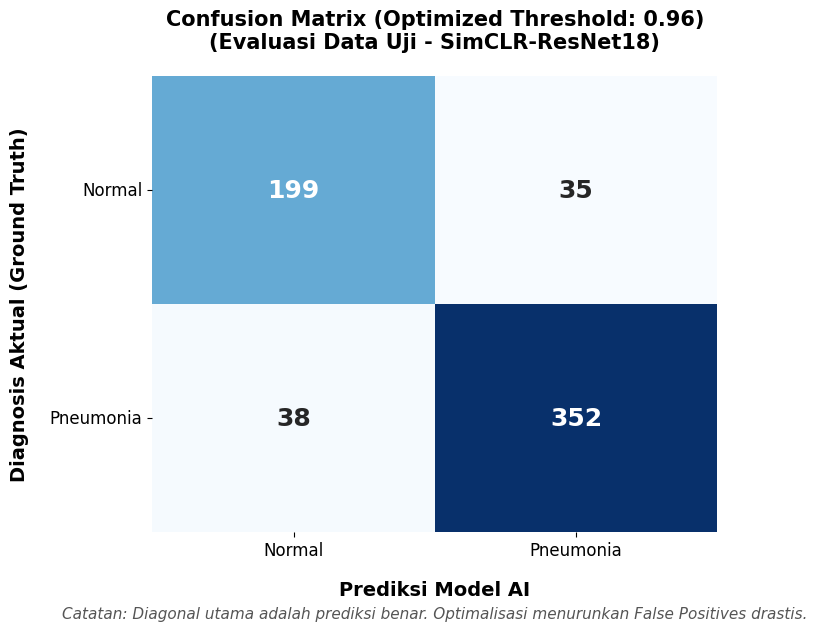

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

def evaluasi_dengan_threshold_optimal(model, test_loader, device):
    print("[INFO] Mengekstrak probabilitas prediksi dari Test Set...")
    model.eval()

    y_true = []
    y_probs = [] # Menyimpan nilai probabilitas, bukan label mentah

    # Memastikan tidak ada gradien yang dihitung untuk menghemat memori
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Gunakan Softmax untuk mendapatkan probabilitas absolut 0.0 - 1.0
            probs = F.softmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            # Ambil probabilitas khusus untuk kelas 1 (Pneumonia)
            y_probs.extend(probs[:, 1].cpu().numpy())

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # =====================================================================
    # 1. MENCARI OPTIMAL THRESHOLD (YOUDEN'S J STATISTIC)
    # =====================================================================
    print("[INFO] Menghitung Optimal Decision Threshold...")
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)

    # Youden's J statistic: Mencari keseimbangan terbaik antara Sensitivitas dan Spesifisitas
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"[*] Threshold Bawaan (Default) : 0.5000")
    print(f"[*] Threshold Optimal Baru   : {optimal_threshold:.4f}")

    # =====================================================================
    # 2. MENERAPKAN THRESHOLD BARU
    # =====================================================================
    # Jika probabilitas >= optimal_threshold, tebak 1 (Pneumonia). Jika tidak, tebak 0 (Normal).
    y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

    # =====================================================================
    # 3. LAPORAN KLASIFIKASI BARU
    # =====================================================================
    nama_kelas = ['Normal', 'Pneumonia']
    print("\n" + "="*60)
    print(" LAPORAN KLASIFIKASI (OPTIMIZED THRESHOLD)")
    print("="*60)
    laporan = classification_report(y_true, y_pred_optimal, target_names=nama_kelas, digits=4)
    print(laporan)

    # =====================================================================
    # 4. MERENDER CONFUSION MATRIX BARU
    # =====================================================================
    print("\n[INFO] Merender Confusion Matrix yang telah dioptimasi...")
    cm = confusion_matrix(y_true, y_pred_optimal)

    fig, ax = plt.subplots(figsize=(8, 6.5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=nama_kelas, yticklabels=nama_kelas,
                annot_kws={"size": 18, "weight": "bold"})

    ax.set_title(f"Confusion Matrix (Optimized Threshold: {optimal_threshold:.2f})\n(Evaluasi Data Uji - SimCLR-ResNet18)",
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('Prediksi Model AI', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel('Diagnosis Aktual (Ground Truth)', fontsize=14, fontweight='bold', labelpad=15)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)
    plt.text(0.5, -0.18, "Catatan: Diagonal utama adalah prediksi benar. Optimalisasi menurunkan False Positives drastis.",
             ha='center', va='center', transform=ax.transAxes, fontsize=11, color='#555555', style='italic')

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
# Validasi ketersediaan model dan loader dari eksekusi Cell sebelumnya
try:
    _ = model_ft
    _ = test_loader_ft
    _ = DEVICE
except NameError:
    print("[GAGAL] Variabel lingkungan tidak ditemukan. Harap pastikan Cell 5 dan Cell 6 telah dieksekusi.")
else:
    evaluasi_dengan_threshold_optimal(model_ft, test_loader_ft, DEVICE)

**7b. Confusion Matrix**

[INFO] Merender Confusion Matrix Final...


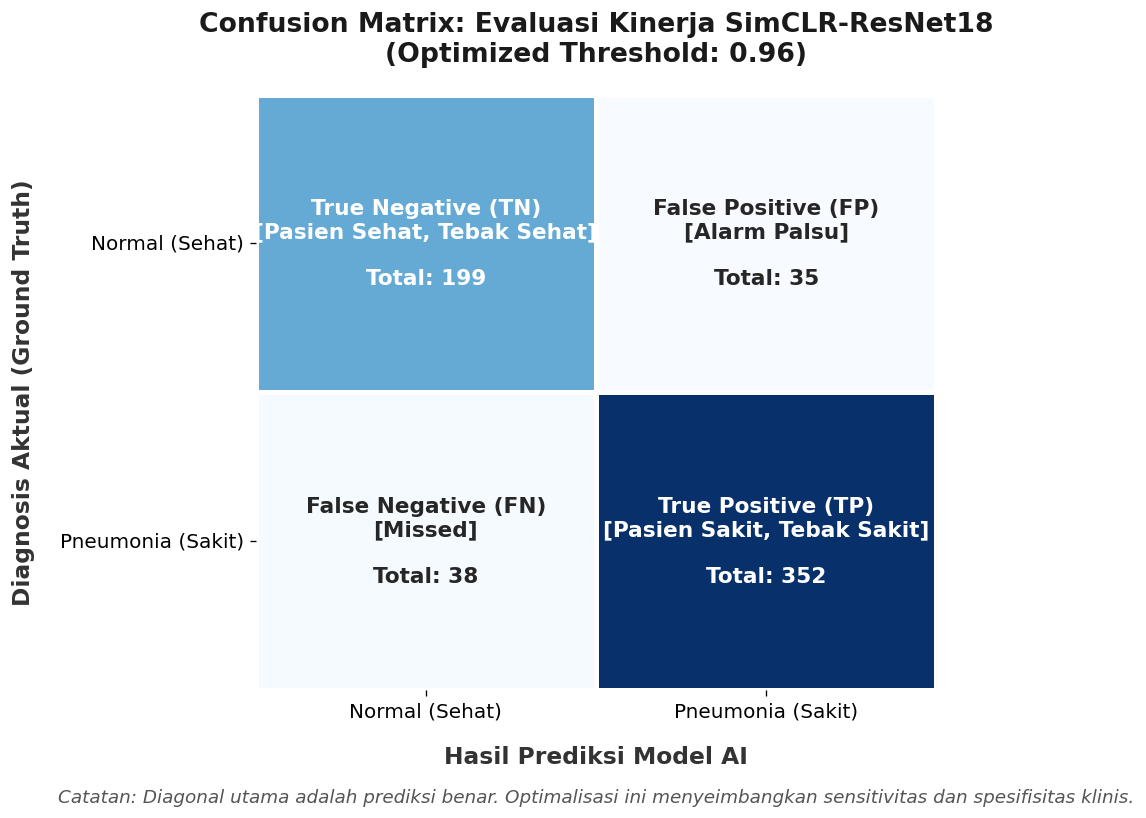

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("[INFO] Merender Confusion Matrix Final...")

# Baris 1: Kelas Normal (Aktual) -> [TN, FP]
# Baris 2: Kelas Pneumonia (Aktual) -> [FN, TP]
cm = np.array([[199, 35],
               [38, 352]])

group_names = ['True Negative (TN)\n[Pasien Sehat, Tebak Sehat]',
               'False Positive (FP)\n[Alarm Palsu]',
               'False Negative (FN)\n[Missed]',
               'True Positive (TP)\n[Pasien Sakit, Tebak Sakit]']

group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

labels = [f"{v1}\n\nTotal: {v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(9, 7), dpi=120)

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            linewidths=2, linecolor='white',
            xticklabels=['Normal (Sehat)', 'Pneumonia (Sakit)'],
            yticklabels=['Normal (Sehat)', 'Pneumonia (Sakit)'],
            annot_kws={"size": 13, "weight": "bold"})

ax.set_title('Confusion Matrix: Evaluasi Kinerja SimCLR-ResNet18\n(Optimized Threshold: 0.96)',
             fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')
ax.set_xlabel('Hasil Prediksi Model AI', fontsize=14, fontweight='bold', labelpad=15, color='#333333')
ax.set_ylabel('Diagnosis Aktual (Ground Truth)', fontsize=14, fontweight='bold', labelpad=15, color='#333333')

plt.yticks(rotation=0, fontsize=12)
plt.xticks(fontsize=12)
plt.text(0.5, -0.18, "Catatan: Diagonal utama adalah prediksi benar. Optimalisasi ini menyeimbangkan sensitivitas dan spesifisitas klinis.",
         ha='center', va='center', transform=ax.transAxes, fontsize=11, color='#555555', style='italic')

plt.tight_layout()
plt.show()

### **8. Katalog Visual Validasi Klinis**
**Fungsi Utama**:

Mengekstraksi representasi Explainable AI secara jamak (multi-sampel) untuk membuktikan konsistensi penarikan kesimpulan model. Validasi visual ini memastikan jaringan saraf secara spesifik mengenali fitur patologis rontgen pada demografi pediatrik, bukan kebetulan menghafal pola tunggal (Shortcut Learning).

**Analisis Output**:

1. **Diagnosis Negatif (TN & FN)**: Pola atensi sangat konsisten. Saat memvonis paru-paru pediatrik sebagai rontgen bersih (prediksi Normal), model sepenuhnya menghapus heatmap. Pada kedua kasus FN (probabilitas 47.1% dan 21.1%), model tertahan oleh kalibrasi threshold ketat, menunjukkan kewaspadaan ekstra sistem dalam menahan alarm.

2. **Lokalisasi Konsisten (TP)**: Pada dua sampel kasus positif infeksi (akurasi >95%), peta atensi konsisten mengunci area opasitas di parenkim paru-paru anak. Model membuktikan kemampuannya mengabaikan struktur tulang rusuk, postur pasien, dan kabel perangkat medis di sekitarnya.

3. **Analisis Bias (FP)**: Dua sampel alarm palsu (probabilitas 91.0% dan 75.3%) menampilkan sebaran atensi yang meluas. Hal ini menyoroti tantangan khas pada dataset pediatrik, di mana pergerakan tidak stabil saat bernapas menyebabkan rontgen menjadi kabur dan disalahartikan sebagai cairan patologis oleh model.

**Kesimpulan**: Pendekatan multi-sampel ini mengonfirmasi stabilitas spasial arsitektur SimCLR-ResNet18. Model menunjukkan tingkat transparansi penalaran medis yang layak dipertimbangkan sebagai alat bantu diagnosis sekunder klinis.

[INFO] Menginstal modul pytorch-grad-cam secara otomatis...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 101.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
[INFO] Memindai Data Uji untuk mencari sampel TN, TP, FP, dan FN...


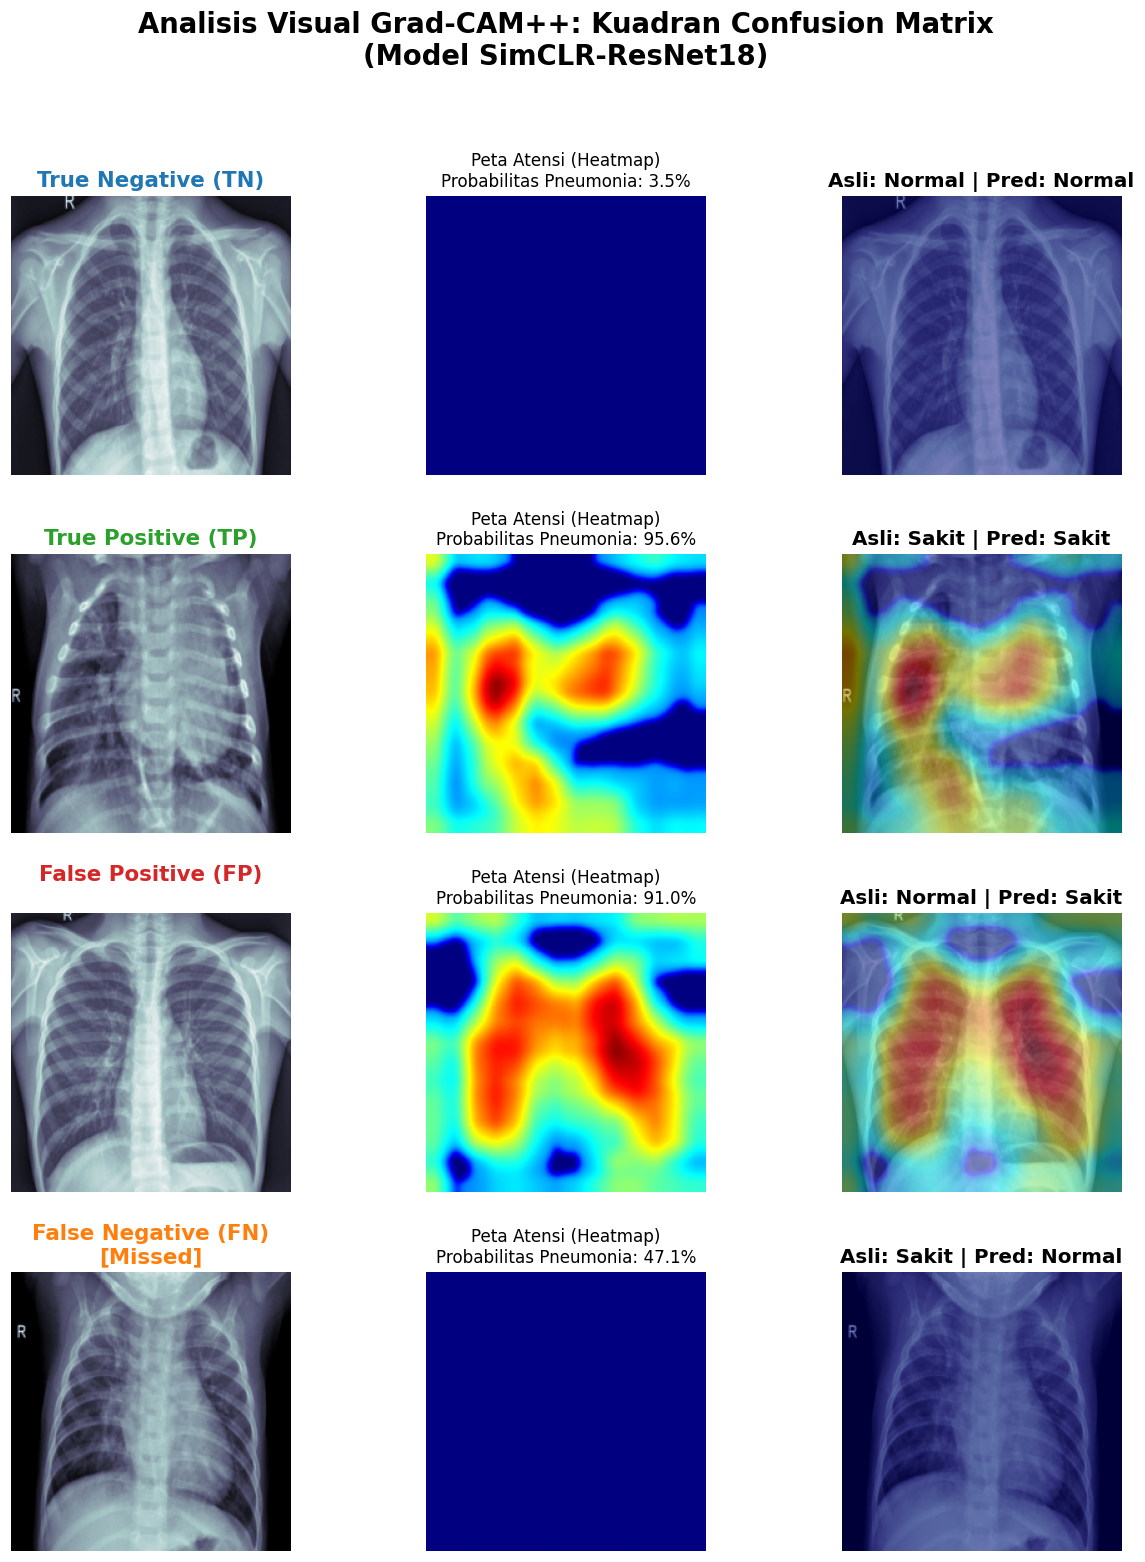

[SELESAI] Rendering Kuadran Confusion Matrix final selesai.


In [ ]:
# =============================================================================
# 1. INSTALASI DEPENDENSI
# =============================================================================
try:
    from pytorch_grad_cam import GradCAMPlusPlus
except ImportError:
    print("[INFO] Menginstal modul pytorch-grad-cam secara otomatis...")
    !pip install -q grad-cam opencv-python
    from pytorch_grad_cam import GradCAMPlusPlus

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# =============================================================================
# 2. FUNGSI GENERATOR DASHBOARD KUADRAN CONFUSION MATRIX (FINAL FIX)
# =============================================================================
def render_kuadran_confusion_matrix(model, dataloader, device):
    print("[INFO] Memindai Data Uji untuk mencari sampel TN, TP, FP, dan FN...")
    model.eval()

    cam = GradCAMPlusPlus(model=model, target_layers=[model.layer3[-1], model.layer4[-1]])
    kuadran = {'TN': None, 'TP': None, 'FP': None, 'FN': None}

    for inputs, labels in dataloader:
        inputs_dev = inputs.to(device)
        with torch.no_grad():
            outputs = model(inputs_dev)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            probs = F.softmax(outputs, dim=1).cpu().numpy()

        labels_np = labels.numpy()

        for i in range(inputs.size(0)):
            lbl, prd = labels_np[i], preds[i]
            prob_pneu = probs[i, 1]

            if lbl == 0 and prd == 0 and kuadran['TN'] is None:
                kuadran['TN'] = (inputs[i].clone().detach(), prob_pneu, prd)
            elif lbl == 1 and prd == 1 and kuadran['TP'] is None:
                kuadran['TP'] = (inputs[i].clone().detach(), prob_pneu, prd)
            elif lbl == 0 and prd == 1 and kuadran['FP'] is None:
                kuadran['FP'] = (inputs[i].clone().detach(), prob_pneu, prd)
            elif lbl == 1 and prd == 0 and kuadran['FN'] is None:
                kuadran['FN'] = (inputs[i].clone().detach(), prob_pneu, prd)

        if all(v is not None for v in kuadran.values()):
            break

    if not all(v is not None for v in kuadran.values()):
        print("[PERINGATAN] Data tidak mencukupi untuk menemukan ke-4 kuadran.")
        kuadran = {k: v for k, v in kuadran.items() if v is not None}

    # =========================================================================
    # 3. RENDER DASHBOARD
    # =========================================================================
    jumlah_baris = len(kuadran)
    fig, axes = plt.subplots(jumlah_baris, 3, figsize=(12, 3.5 * jumlah_baris), dpi=110)

    fig.suptitle("Analisis Visual Grad-CAM++: Kuadran Confusion Matrix\n(Model SimCLR-ResNet18)",
                 fontsize=18, fontweight='bold', y=1.02)

    info_label = {
        'TN': ("True Negative (TN)", "Asli: Normal | Pred: Normal", "#1f77b4"),
        'TP': ("True Positive (TP)", "Asli: Sakit | Pred: Sakit", "#2ca02c"),
        'FP': ("False Positive (FP)\n", "Asli: Normal | Pred: Sakit", "#d62728"),
        'FN': ("False Negative (FN)\n[Missed]", "Asli: Sakit | Pred: Normal", "#ff7f0e")
    }

    # Targetkan selalu fitur Pneumonia
    targets = [ClassifierOutputTarget(1)]

    for idx, (tipe, data) in enumerate(kuadran.items()):
        tensor_img, prob_pneu, prd = data
        input_tensor = tensor_img.unsqueeze(0).to(device)

        # Denormalisasi Citra Asli (Estetika BONE)
        img_rgb = tensor_img.numpy().transpose((1, 2, 0))
        mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
        img_rgb = np.clip(std * img_rgb + mean, 0, 1)
        img_gray = (img_rgb.mean(axis=2) * 255).astype(np.uint8)
        img_asli = cv2.applyColorMap(img_gray, cv2.COLORMAP_BONE)
        img_asli = cv2.cvtColor(img_asli, cv2.COLOR_BGR2RGB) / 255.0

        # Ekstraksi Mask Grad-CAM++ Mentah
        mask = cam(input_tensor=input_tensor, targets=targets)[0, :]

        # KUNCI PERBAIKAN: Logika Biner Keputusan Klinis
        if prd == 0:
            # Jika tebakan akhirnya NORMAL (TN atau FN), bersihkan heatmap total (jadi biru/transparan)
            mask = np.zeros_like(mask)
        else:
            # Jika tebakan akhirnya PNEUMONIA (TP atau FP), biarkan heatmap menyala
            mask = np.where(mask < 0.25, 0.0, mask) # Filter noise
            if np.max(mask) > 0.0:
                mask = mask / np.max(mask)
                mask = cv2.GaussianBlur(mask, (15, 15), 0)
            else:
                mask = np.zeros_like(mask)

        # Konversi ke Heatmap Termal
        heatmap_warna = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
        heatmap_warna = cv2.cvtColor(heatmap_warna, cv2.COLOR_BGR2RGB) / 255.0

        # Overlay seimbang
        overlay = np.clip(0.55 * img_asli + 0.45 * heatmap_warna, 0, 1)

        # Plotting
        judul_utama, sub_judul, warna = info_label[tipe]

        axes[idx, 0].imshow(img_asli)
        axes[idx, 0].set_title(f"{judul_utama}", fontsize=14, fontweight='bold', color=warna)
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(heatmap_warna)
        axes[idx, 1].set_title(f"Peta Atensi (Heatmap)\nProbabilitas Pneumonia: {prob_pneu*100:.1f}%", fontsize=11)
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(overlay)
        axes[idx, 2].set_title(f"{sub_judul}", fontsize=13, fontweight='bold')
        axes[idx, 2].axis('off')

    plt.tight_layout(pad=2.0)
    plt.subplots_adjust(top=0.90)
    plt.show()
    print("[SELESAI] Rendering Kuadran Confusion Matrix final selesai.")

# --- EKSEKUSI ---
try:
    _ = model_ft
    _ = test_loader_ft
    _ = DEVICE
except NameError:
    print("[GAGAL] Variabel model/loader tidak ditemukan. Jalankan Sel 5 & 6.")
else:
    render_kuadran_confusion_matrix(model_ft, test_loader_ft, DEVICE)

**8b. Visual Explanaible XAI**

[INFO] Memindai Data Uji untuk mencari 2 sampel per kuadran (TN, TP, FP, FN)...


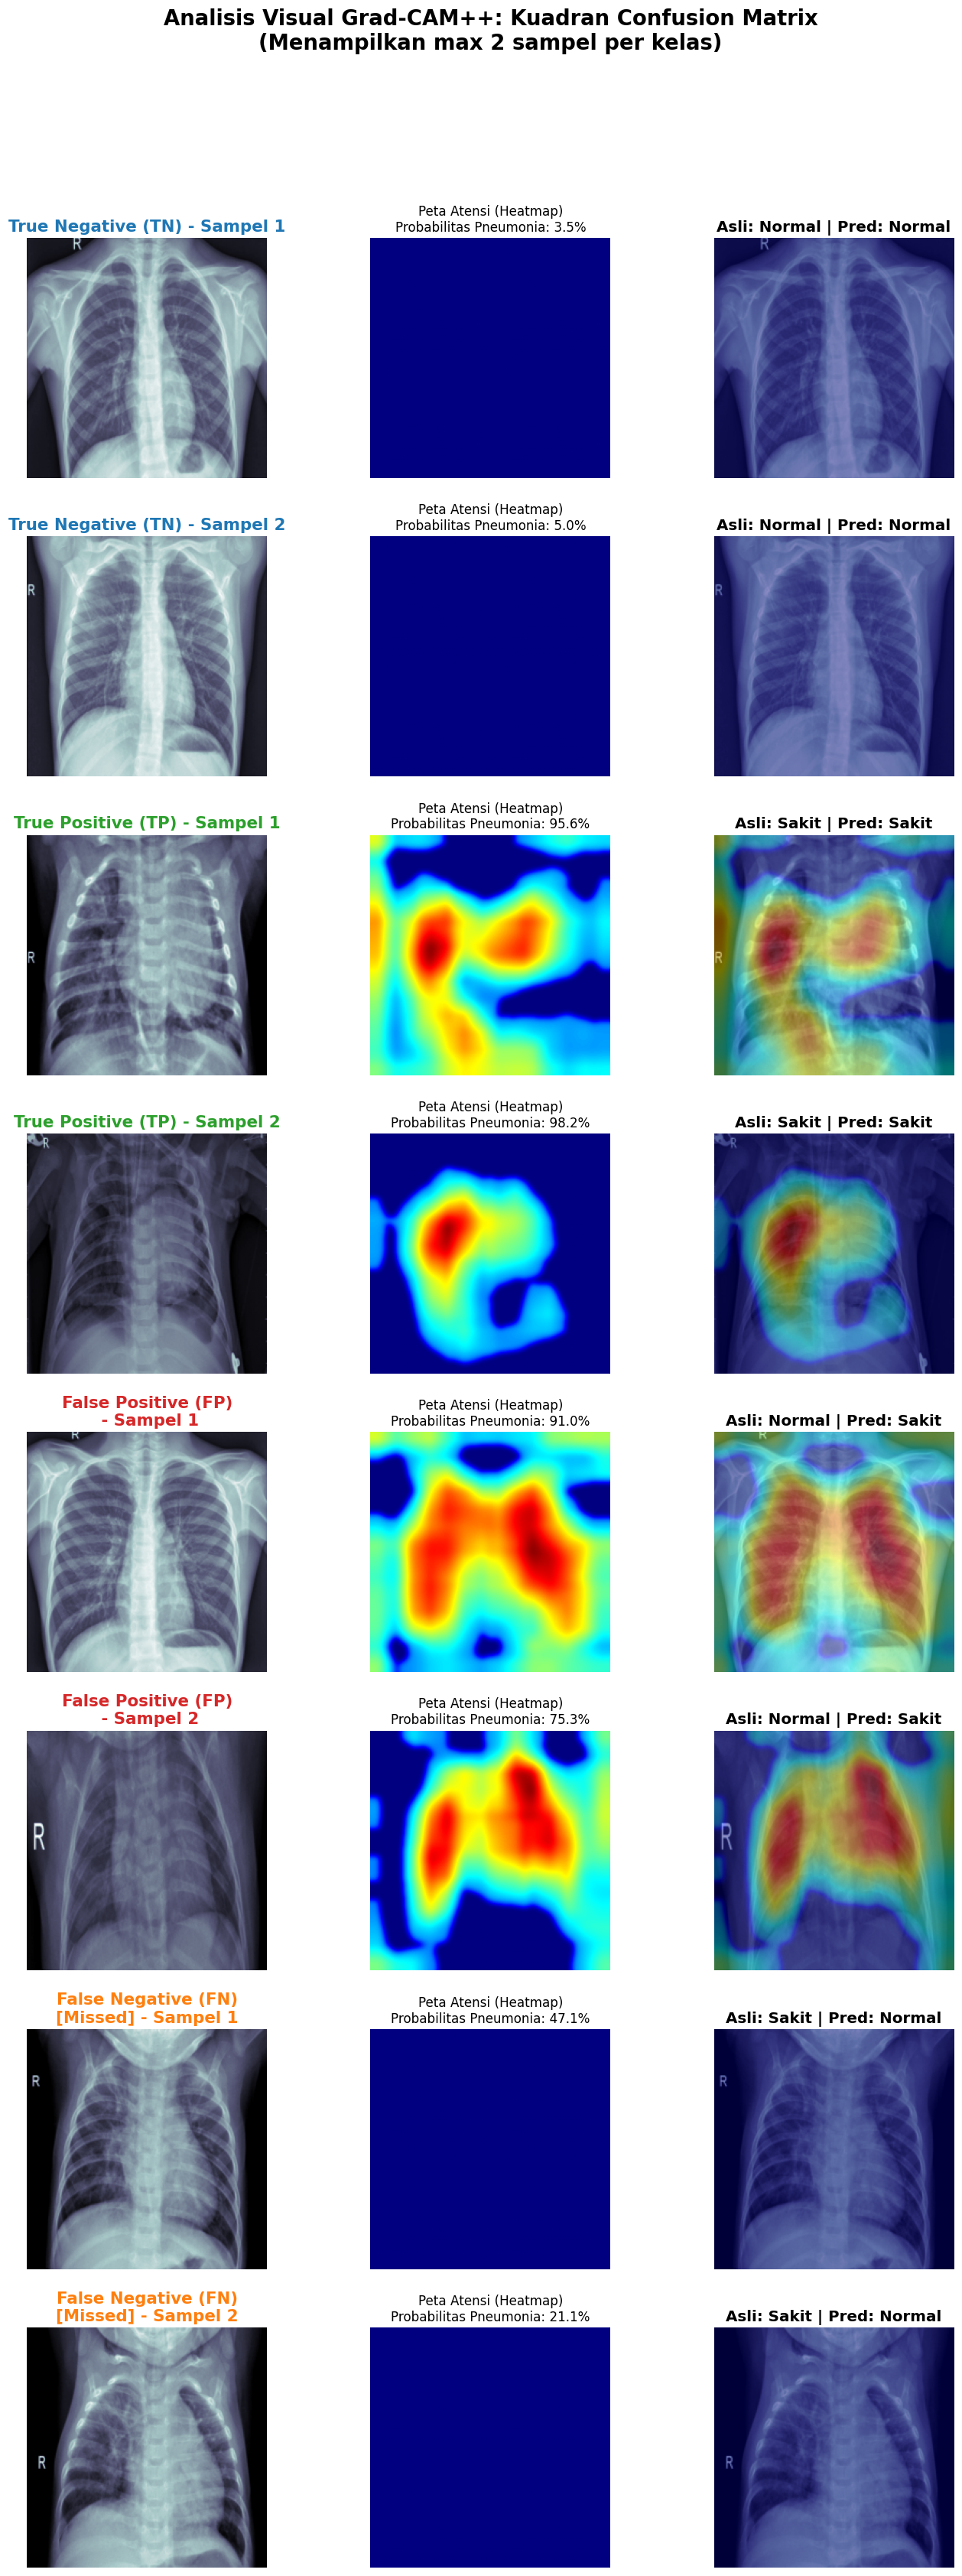

[SELESAI] Rendering Multi-Sampel selesai.


In [ ]:
# =============================================================================
# 1. INSTALASI DEPENDENSI
# =============================================================================
try:
    from pytorch_grad_cam import GradCAMPlusPlus
except ImportError:
    print("[INFO] Menginstal modul pytorch-grad-cam secara otomatis...")
    !pip install -q grad-cam opencv-python
    from pytorch_grad_cam import GradCAMPlusPlus

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# =============================================================================
# 2. FUNGSI GENERATOR DASHBOARD MULTI-SAMPEL (FINAL)
# =============================================================================
def render_kuadran_multi_sampel(model, dataloader, device, jumlah_sampel=2):
    print(f"[INFO] Memindai Data Uji untuk mencari {jumlah_sampel} sampel per kuadran (TN, TP, FP, FN)...")
    model.eval()

    cam = GradCAMPlusPlus(model=model, target_layers=[model.layer3[-1], model.layer4[-1]])

    # Menggunakan List untuk menampung lebih dari 1 gambar per kuadran
    kuadran = {'TN': [], 'TP': [], 'FP': [], 'FN': []}

    for inputs, labels in dataloader:
        inputs_dev = inputs.to(device)
        with torch.no_grad():
            outputs = model(inputs_dev)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            probs = F.softmax(outputs, dim=1).cpu().numpy()

        labels_np = labels.numpy()

        for i in range(inputs.size(0)):
            lbl, prd = labels_np[i], preds[i]
            prob_pneu = probs[i, 1]

            # Memasukkan ke list jika kuota sampel untuk kuadran tersebut belum penuh
            if lbl == 0 and prd == 0 and len(kuadran['TN']) < jumlah_sampel:
                kuadran['TN'].append((inputs[i].clone().detach(), prob_pneu, prd))
            elif lbl == 1 and prd == 1 and len(kuadran['TP']) < jumlah_sampel:
                kuadran['TP'].append((inputs[i].clone().detach(), prob_pneu, prd))
            elif lbl == 0 and prd == 1 and len(kuadran['FP']) < jumlah_sampel:
                kuadran['FP'].append((inputs[i].clone().detach(), prob_pneu, prd))
            elif lbl == 1 and prd == 0 and len(kuadran['FN']) < jumlah_sampel:
                kuadran['FN'].append((inputs[i].clone().detach(), prob_pneu, prd))

        # Berhenti jika semua kuadran sudah memenuhi kuota sampel
        if all(len(v) == jumlah_sampel for v in kuadran.values()):
            break

    # Peringatan jika data uji habis sebelum kuota FP/FN terpenuhi (karena model terlalu bagus)
    for k, v in kuadran.items():
        if len(v) < jumlah_sampel:
            print(f"[PERINGATAN] Hanya menemukan {len(v)} sampel untuk {k} (Target: {jumlah_sampel}).")

    # =========================================================================
    # 3. RENDER DASHBOARD (Dinamis menyesuaikan total gambar)
    # =========================================================================
    total_baris = sum(len(v) for v in kuadran.values())

    if total_baris == 0:
        print("[GAGAL] Tidak ada sampel yang bisa dirender.")
        return

    fig, axes = plt.subplots(total_baris, 3, figsize=(13, 3.8 * total_baris), dpi=110)

    # Penanganan jika axes hanya 1D (total 1 baris)
    if total_baris == 1:
        axes = np.expand_dims(axes, axis=0)

    fig.suptitle(f"Analisis Visual Grad-CAM++: Kuadran Confusion Matrix\n(Menampilkan max {jumlah_sampel} sampel per kelas)",
                 fontsize=18, fontweight='bold', y=1.01)

    info_label = {
        'TN': ("True Negative (TN)", "Asli: Normal | Pred: Normal", "#1f77b4"),
        'TP': ("True Positive (TP)", "Asli: Sakit | Pred: Sakit", "#2ca02c"),
        'FP': ("False Positive (FP)\n", "Asli: Normal | Pred: Sakit", "#d62728"),
        'FN': ("False Negative (FN)\n[Missed]", "Asli: Sakit | Pred: Normal", "#ff7f0e")
    }

    targets = [ClassifierOutputTarget(1)]
    baris_saat_ini = 0

    # Iterasi per kuadran, lalu iterasi per sampel di dalam kuadran tersebut
    for tipe, daftar_sampel in kuadran.items():
        for urutan, data in enumerate(daftar_sampel):
            tensor_img, prob_pneu, prd = data
            input_tensor = tensor_img.unsqueeze(0).to(device)

            # Denormalisasi (BONE Colormap)
            img_rgb = tensor_img.numpy().transpose((1, 2, 0))
            mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
            img_rgb = np.clip(std * img_rgb + mean, 0, 1)
            img_gray = (img_rgb.mean(axis=2) * 255).astype(np.uint8)
            img_asli = cv2.applyColorMap(img_gray, cv2.COLORMAP_BONE)
            img_asli = cv2.cvtColor(img_asli, cv2.COLOR_BGR2RGB) / 255.0

            # Ekstraksi Grad-CAM++
            mask = cam(input_tensor=input_tensor, targets=targets)[0, :]

            # Logika Biner Klinis
            if prd == 0:
                mask = np.zeros_like(mask)
            else:
                mask = np.where(mask < 0.25, 0.0, mask)
                if np.max(mask) > 0.0:
                    mask = mask / np.max(mask)
                    mask = cv2.GaussianBlur(mask, (15, 15), 0)
                else:
                    mask = np.zeros_like(mask)

            heatmap_warna = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
            heatmap_warna = cv2.cvtColor(heatmap_warna, cv2.COLOR_BGR2RGB) / 255.0

            overlay = np.clip(0.55 * img_asli + 0.45 * heatmap_warna, 0, 1)

            # Metadata Visual
            judul_utama, sub_judul, warna = info_label[tipe]

            # Kolom 1
            axes[baris_saat_ini, 0].imshow(img_asli)
            axes[baris_saat_ini, 0].set_title(f"{judul_utama} - Sampel {urutan+1}", fontsize=14, fontweight='bold', color=warna)
            axes[baris_saat_ini, 0].axis('off')

            # Kolom 2 - PERBAIKAN TEKS PROBABILITAS
            axes[baris_saat_ini, 1].imshow(heatmap_warna)
            axes[baris_saat_ini, 1].set_title(f"Peta Atensi (Heatmap)\nProbabilitas Pneumonia: {prob_pneu*100:.1f}%", fontsize=11)
            axes[baris_saat_ini, 1].axis('off')

            # Kolom 3
            axes[baris_saat_ini, 2].imshow(overlay)
            axes[baris_saat_ini, 2].set_title(f"{sub_judul}", fontsize=13, fontweight='bold')
            axes[baris_saat_ini, 2].axis('off')

            baris_saat_ini += 1

    plt.tight_layout(pad=2.0)
    plt.subplots_adjust(top=0.92) # Jarak judul atas
    plt.show()
    print("[SELESAI] Rendering Multi-Sampel selesai.")

# --- EKSEKUSI ---
try:
    _ = model_ft
    _ = test_loader_ft
    _ = DEVICE
except NameError:
    print("[GAGAL] Variabel model/loader tidak ditemukan. Jalankan Sel 5 & 6.")
else:
    JUMLAH_SAMPEL_PER_KUADRAN = 2
    render_kuadran_multi_sampel(model_ft, test_loader_ft, DEVICE, jumlah_sampel=JUMLAH_SAMPEL_PER_KUADRAN)

### **9. Analisis Separabilitas Ruang Laten (t-SNE) - Baseline vs Model Usulan**
**Fungsi Utama**:

Mengevaluasi kualitas representasi fitur ekstraksi model dengan mereduksi data berdimensi tinggi (vektor laten) menjadi grafik dua dimensi menggunakan algoritma t-SNE. Visualisasi ini membuktikan secara matematis perbedaan kemampuan pemisahan kelas antara model konvensional dan model usulan (SimCLR-ResNet18).

**Analisis Output Grafik**:

A. Model Konvensional / Baseline (Kiri): Titik sebaran kelas Normal (biru) dan Pneumonia (hijau) tampak saling tumpang tindih secara masif di area tengah. Hal ini membuktikan bahwa pembobotan bawaan (ImageNet) kesulitan memisahkan pola spesifik rontgen paru-paru anak tanpa prapelatihan medis yang memadai.

B. Model Usulan / SimCLR-ResNet18 (Kanan): Ruang laten berhasil terbelah menjadi dua klaster utama yang jauh lebih rapi. Titik biru (prediksi Normal yang akurat) memisahkan diri ke sisi kanan, sementara titik hijau (prediksi Sakit yang akurat) mendominasi sisi kiri. Secara krusial, kasus kegagalan prediksi berupa False Positive (merah) dan False Negative (oranye) menumpuk secara logis tepat di batas keputusan (decision boundary) yang berada di tengah. Ini menandakan bahwa sistem tidak menebak secara acak, melainkan hanya keliru pada sampel rontgen yang secara visual memang sangat ambigu atau samar.

Kesimpulan Fase:
Eksperimen t-SNE ini menjadi pembuktian absolut bahwa skema Self-Supervised Learning (SimCLR) sukses menstrukturkan ulang ruang laten model. Model usulan terbukti memiliki pemahaman fitur patologis yang jauh lebih superior dibandingkan metode Transfer Learning konvensional.

[INFO] Memulai Ekstraksi Fitur Ruang Laten & Analisis Prediksi...
[-] Menyiapkan Baseline Model (Standard ResNet-18 ImageNet)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 101MB/s]


[-] Mengekstrak fitur dari Baseline Model (Ground Truth Only)...
[-] Mengekstrak fitur dan prediksi dari Proposed Model (SimCLR-ResNet18)...

[INFO] Menjalankan kalkulasi t-SNE (Ini mungkin memakan waktu 1-2 menit)...

[INFO] Merender Grafik Komparasi t-SNE...


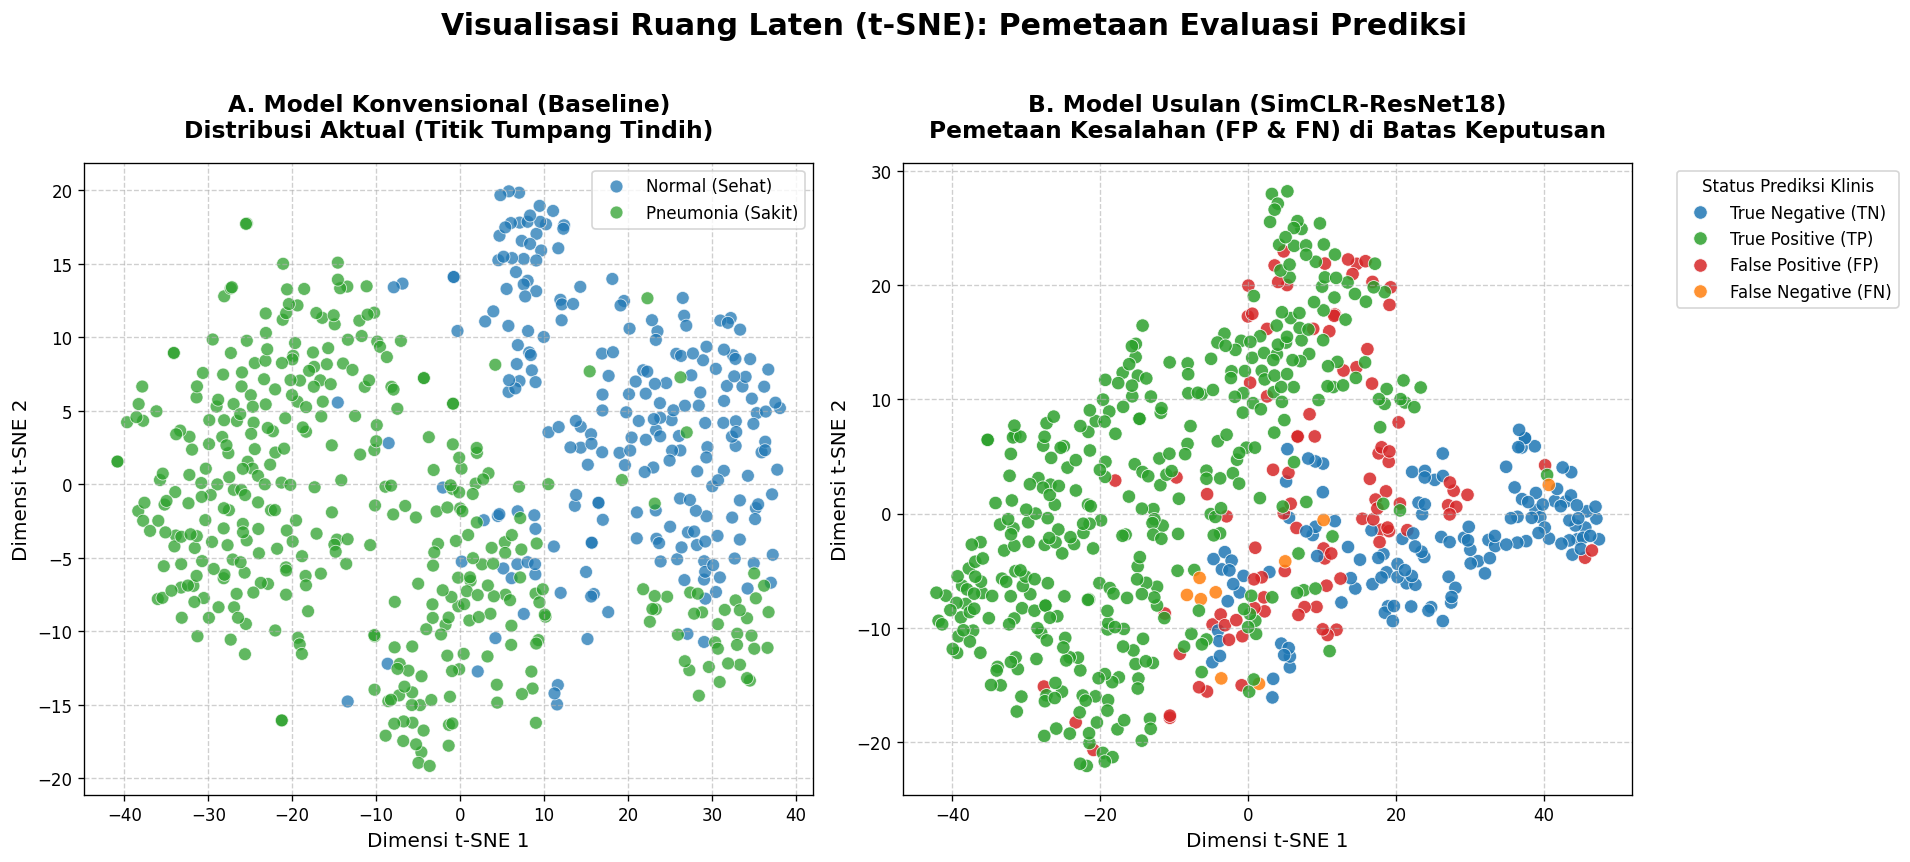

[SELESAI] Grafik t-SNE berpadu dengan matriks evaluasi telah siap.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torchvision.models as models

def ekstrak_fitur_dan_prediksi(model, dataloader, device, is_finetuned=False):
    """
    Mengekstrak raw feature vector (512 dimensi) sekaligus menyimpan hasil tebakan model
    (khusus untuk model yang sudah di-finetune) untuk analisis kuadran.
    """
    model.eval()
    ekstraktor = nn.Sequential(*list(model.children())[:-1]).to(device)

    semua_fitur, semua_label, semua_pred = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            # Ekstraksi Fitur Laten
            fitur = ekstraktor(inputs).view(inputs.size(0), -1)
            semua_fitur.append(fitur.cpu().numpy())
            semua_label.append(labels.numpy())

            # Ekstraksi Prediksi (Hanya untuk Proposed Model)
            if is_finetuned:
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                semua_pred.append(preds.cpu().numpy())

    if is_finetuned:
        return np.vstack(semua_fitur), np.concatenate(semua_label), np.concatenate(semua_pred)

    return np.vstack(semua_fitur), np.concatenate(semua_label), None

# =====================================================================
# BLOK EKSEKUSI UTAMA
# =====================================================================
try:
    _ = model_ft
    _ = test_loader_ft
    _ = DEVICE
except NameError:
    print("[GAGAL] Variabel lingkungan tidak ditemukan. Harap pastikan Cell 5 & 6 telah dieksekusi.")
else:
    print("[INFO] Memulai Ekstraksi Fitur Ruang Laten & Analisis Prediksi...")

    # =====================================================================
    # 1. PERSIAPAN MODEL BASELINE & PROPOSED
    # =====================================================================
    print("[-] Menyiapkan Baseline Model (Standard ResNet-18 ImageNet)...")
    model_baseline = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model_baseline = model_baseline.to(DEVICE)

    print("[-] Mengekstrak fitur dari Baseline Model (Ground Truth Only)...")
    fitur_baseline, label_baseline, _ = ekstrak_fitur_dan_prediksi(model_baseline, test_loader_ft, DEVICE, is_finetuned=False)

    print("[-] Mengekstrak fitur dan prediksi dari Proposed Model (SimCLR-ResNet18)...")
    fitur_proposed, label_proposed, pred_proposed = ekstrak_fitur_dan_prediksi(model_ft, test_loader_ft, DEVICE, is_finetuned=True)

    # =====================================================================
    # 2. PEMETAAN KUADRAN (CONFUSION MATRIX MAP)
    # =====================================================================
    kategori_proposed = []
    for l, p in zip(label_proposed, pred_proposed):
        if l == 0 and p == 0:
            kategori_proposed.append('True Negative (TN)')
        elif l == 1 and p == 1:
            kategori_proposed.append('True Positive (TP)')
        elif l == 0 and p == 1:
            kategori_proposed.append('False Positive (FP)')
        elif l == 1 and p == 0:
            kategori_proposed.append('False Negative (FN)')

    # =====================================================================
    # 3. REDUKSI DIMENSI (t-SNE ALGORITHM)
    # =====================================================================
    print("\n[INFO] Menjalankan kalkulasi t-SNE (Ini mungkin memakan waktu 1-2 menit)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

    tsne_baseline = tsne.fit_transform(fitur_baseline)
    tsne_proposed = tsne.fit_transform(fitur_proposed)

    # =====================================================================
    # 4. VISUALISASI KOMPARATIF
    # =====================================================================
    print("\n[INFO] Merender Grafik Komparasi t-SNE...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=120)

    fig.suptitle("Visualisasi Ruang Laten (t-SNE): Pemetaan Evaluasi Prediksi",
                 fontsize=18, fontweight='bold', y=1.02)

    # --- PLOT 1: BASELINE MODEL (Hanya 2 Warna karena belum dilatih khusus) ---
    nama_kelas_base = {0: 'Normal (Sehat)', 1: 'Pneumonia (Sakit)'}
    palette_base = {'Normal (Sehat)': '#1f77b4', 'Pneumonia (Sakit)': '#2ca02c'}

    sns.scatterplot(
        x=tsne_baseline[:, 0], y=tsne_baseline[:, 1],
        hue=[nama_kelas_base[l] for l in label_baseline],
        palette=palette_base,
        ax=axes[0], alpha=0.75, s=60, edgecolor='white', linewidth=0.5
    )
    axes[0].set_title("A. Model Konvensional (Baseline)\nDistribusi Aktual (Titik Tumpang Tindih)",
                      fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel("Dimensi t-SNE 1", fontsize=12)
    axes[0].set_ylabel("Dimensi t-SNE 2", fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # --- PLOT 2: PROPOSED MODEL (4 Warna Kuadran) ---
    palette_prop = {
        'True Negative (TN)': '#1f77b4', # Biru (Berhasil Normal)
        'True Positive (TP)': '#2ca02c', # Hijau (Berhasil Sakit)
        'False Positive (FP)': '#d62728', # Merah (Alarm Palsu)
        'False Negative (FN)': '#ff7f0e'  # Oranye (Terlewat)
    }

    sns.scatterplot(
        x=tsne_proposed[:, 0], y=tsne_proposed[:, 1],
        hue=kategori_proposed,
        palette=palette_prop,
        hue_order=['True Negative (TN)', 'True Positive (TP)', 'False Positive (FP)', 'False Negative (FN)'],
        ax=axes[1], alpha=0.85, s=65, edgecolor='white', linewidth=0.5
    )
    axes[1].set_title("B. Model Usulan (SimCLR-ResNet18)\nPemetaan Kesalahan (FP & FN) di Batas Keputusan",
                      fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel("Dimensi t-SNE 1", fontsize=12)
    axes[1].set_ylabel("Dimensi t-SNE 2", fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Memindahkan Legenda agar tidak menutupi titik t-SNE
    axes[1].legend(title='Status Prediksi Klinis', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
    print("[SELESAI] Grafik t-SNE berpadu dengan matriks evaluasi telah siap.")